In [24]:
from pathlib import Path
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA, KernelPCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.manifold import TSNE
from tqdm import tqdm
import seaborn as sns
import time

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")

Path("../model").mkdir(parents=True, exist_ok=True)
Path("../result").mkdir(parents=True, exist_ok=True)

torch.manual_seed(42)
np.random.seed(42)

import warnings
warnings.filterwarnings('ignore')

Using device: mps


# Task 1 - PCA or Kernel PCA

### Load MNIST dataset

In [25]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform)

full_x = torch.cat([train_dataset.data.float(), test_dataset.data.float()])
full_y = torch.cat([train_dataset.targets, test_dataset.targets])

n_samples = full_x.shape[0]
flat_x = full_x.reshape(n_samples, -1)

print(f"Dataset shape: {flat_x.shape}")
print(f"Labels shape: {full_y.shape}")

X_np = flat_x.numpy()
y_np = full_y.numpy()

Dataset shape: torch.Size([70000, 784])
Labels shape: torch.Size([70000])


In [26]:
def visualize_components(components, title, n_to_show=10):
    """Visualize principal components as images"""
    n_components_to_show = min(n_to_show, len(components))
    rows = (n_components_to_show + 4) // 5
    cols = min(5, n_components_to_show)
    
    plt.figure(figsize=(cols * 2.5, rows * 2.5))
    for i in range(n_components_to_show):
        plt.subplot(rows, cols, i + 1)
        component_img = components[i].reshape(28, 28)
        plt.imshow(component_img, cmap='viridis')
        plt.title(f"PC {i+1}")
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.savefig(f"../result/{title.replace(' ', '_').replace(':', '')}.png")
    plt.show()

def plot_embeddings(embeddings, labels, title):
    """Plot 2D embeddings colored by digit class"""
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(embeddings[:, 0], embeddings[:, 1], c=labels, 
                         cmap='tab10', alpha=0.5, s=5)
    plt.colorbar(scatter, label='Digit')
    plt.title(title)
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.tight_layout()
    plt.savefig(f"../result/{title.replace(' ', '_').replace(':', '')}.png")
    plt.show()

In [27]:
def evaluate_separation(embeddings, y):
    """Evaluate cluster separation metrics"""
    means = {}
    for digit in range(10):
        digit_points = embeddings[y == digit]
        means[digit] = np.mean(digit_points, axis=0)
    
    distances = []
    for i in range(10):
        for j in range(i+1, 10):
            dist = np.linalg.norm(means[i] - means[j])
            distances.append(dist)
    
    intra_distances = []
    for digit in range(10):
        digit_points = embeddings[y == digit]
        digit_mean = means[digit]
        for point in digit_points:
            intra_dist = np.linalg.norm(point - digit_mean)
            intra_distances.append(intra_dist)
    
    avg_inter_distance = np.mean(distances)
    avg_intra_distance = np.mean(intra_distances)
    separation_ratio = avg_inter_distance / avg_intra_distance
    
    return {
        'avg_inter_distance': avg_inter_distance,
        'avg_intra_distance': avg_intra_distance,
        'separation_ratio': separation_ratio
    }

In [28]:
class SimpleClassifier(nn.Module):
    """Simple neural network classifier"""
    
    def __init__(self, input_dim, hidden_dim=50):
        super(SimpleClassifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 10)
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
def train_nn_classifier(X, y, n_components, method_name):
    """Train and evaluate neural network classifier"""
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.long)
    
    indices = torch.randperm(len(X_tensor))
    train_size = int(0.8 * len(X_tensor))
    train_indices = indices[:train_size]
    test_indices = indices[train_size:]
    
    X_train_tensor, X_test_tensor = X_tensor[train_indices], X_tensor[test_indices]
    y_train_tensor, y_test_tensor = y_tensor[train_indices], y_tensor[test_indices]
    
    if n_components <= 10:
        hidden_dim = 20
    elif n_components <= 50:
        hidden_dim = 50
    else:
        hidden_dim = 100
    
    model = SimpleClassifier(input_dim=n_components, hidden_dim=hidden_dim)
    criterion = nn.CrossEntropyLoss()
    
    if n_components <= 10:
        lr = 0.01
    elif n_components <= 50:
        lr = 0.005
    else:
        lr = 0.001
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    if n_components <= 10:
        num_epochs = 200
    elif n_components <= 50:
        num_epochs = 150
    else:
        num_epochs = 100
    
    batch_size = 128
    n_batches = max(len(X_train_tensor) // batch_size, 1)
    history = {
        'loss': [],
        'accuracy': [],
        'val_loss': [],
        'val_accuracy': []
    }
    
    pbar = tqdm(range(num_epochs), desc=f"Training NN on {method_name} (n={n_components})")
    for epoch in pbar:
        model.train()
        epoch_loss = 0.0
        correct = 0
        total = 0

        perm_indices = torch.randperm(len(X_train_tensor))

        for i in range(0, len(X_train_tensor), batch_size):
            batch_indices = perm_indices[i:min(i+batch_size, len(X_train_tensor))]
            batch_X = X_train_tensor[batch_indices]
            batch_y = y_train_tensor[batch_indices]

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == batch_y).sum().item()
            total += batch_y.size(0)

        avg_loss = epoch_loss / n_batches
        train_accuracy = correct / total
        
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_test_tensor)
            val_loss = criterion(val_outputs, y_test_tensor).item()
            _, val_predicted = torch.max(val_outputs.data, 1)
            val_accuracy = (val_predicted == y_test_tensor).sum().item() / len(y_test_tensor)
        
        history['loss'].append(avg_loss)
        history['accuracy'].append(train_accuracy)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_accuracy)
        
        pbar.set_postfix({
            'loss': f"{avg_loss:.4f}", 
            'acc': f"{train_accuracy:.4f}",
            'val_acc': f"{val_accuracy:.4f}"
        })

        if (epoch + 1) % (num_epochs // 4) == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, "
                  f"Accuracy: {train_accuracy:.4f}, Val Accuracy: {val_accuracy:.4f}")
    
    model.eval()
    with torch.no_grad():
        outputs = model(X_test_tensor)
        _, predicted = torch.max(outputs.data, 1)
        test_accuracy = (predicted == y_test_tensor).sum().item() / len(y_test_tensor)
        conf_matrix = confusion_matrix(y_test_tensor.numpy(), predicted.numpy())
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['accuracy'], label='Train')
    plt.plot(history['val_accuracy'], label='Validation')
    plt.title(f'SimpleNN Accuracy on {method_name} (n={n_components})')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(history['loss'], label='Train')
    plt.plot(history['val_loss'], label='Validation')
    plt.title(f'SimpleNN Loss on {method_name} (n={n_components})')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"../result/SimpleNN_{method_name}_n{n_components}_training.png")
    plt.show()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(f'SimpleNN Confusion Matrix on {method_name} (n={n_components})')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(f"../result/SimpleNN_{method_name}_n{n_components}_confmat.png")
    plt.show()
    
    return model, test_accuracy, history, conf_matrix

In [30]:
def train_knn_classifier(X, y, n_components, method_name):
    """Train and evaluate KNN classifier"""
    indices = np.random.permutation(len(X))
    train_size = int(0.8 * len(X))
    train_indices = indices[:train_size]
    test_indices = indices[train_size:]
    
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]
    
    if n_components <= 10:
        n_neighbors = 5
    elif n_components <= 50:
        n_neighbors = 3
    else:
        n_neighbors = 3
    
    print(f"Training KNN on {method_name} (n={n_components})...")
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_train, y_train)
    
    y_pred = knn.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(f'KNN Confusion Matrix on {method_name} (n={n_components})')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(f"../result/KNN_{method_name}_n{n_components}_confmat.png")
    plt.show()
    
    print(f"KNN on {method_name} (n={n_components}) - Test Accuracy: {test_accuracy:.4f}")
    return knn, test_accuracy, conf_matrix


In [31]:
def visualize_reconstruction(X_original, X_reconstructed, y, n_samples=5, title=''):
    """Visualize original vs reconstructed images"""
    sample_indices = range(n_samples)
    
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(sample_indices):
        plt.subplot(2, n_samples, i + 1)
        plt.imshow(X_original[idx].reshape(28, 28), cmap='gray')
        plt.title(f"Original: {y[idx]}")
        plt.axis('off')
        
        plt.subplot(2, n_samples, i + 1 + n_samples)
        plt.imshow(X_reconstructed[idx].reshape(28, 28), cmap='gray')
        plt.title(f"Reconstructed")
        plt.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.savefig(f"../result/{title.replace(' ', '_').replace(':', '')}.png")
    plt.show()

In [32]:
all_results = []

### `n_components = 2`

In [33]:
n_components = 2

#### PCA


Performing PCA with n_components=2...
PCA completed in 0.07 seconds
Explained variance ratio: [0.09746247 0.07155529]
Total explained variance: 0.1690


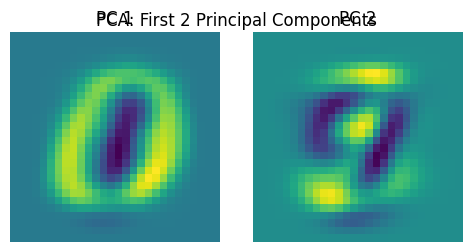

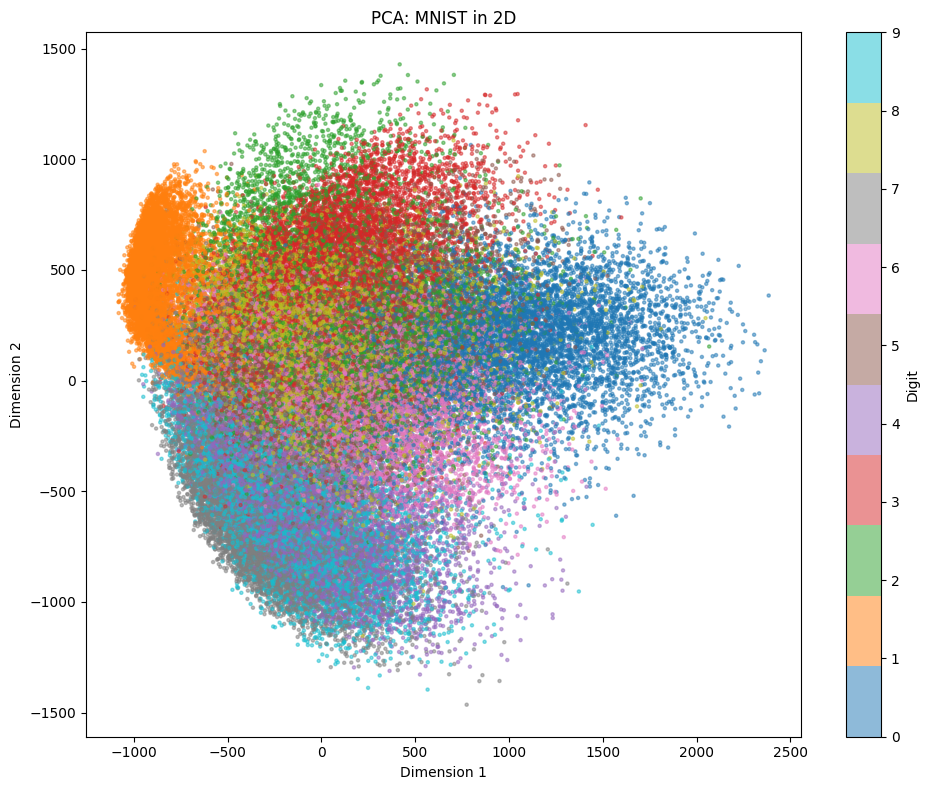

In [34]:
print(f"\nPerforming PCA with n_components={n_components}...")
start_time = time.time()
pca = PCA(n_components=n_components)
pca_result = pca.fit_transform(X_np)
print(f"PCA completed in {time.time() - start_time:.2f} seconds")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {sum(pca.explained_variance_ratio_):.4f}")

visualize_components(pca.components_, f"PCA: First {n_components} Principal Components", n_to_show=2)

plot_embeddings(pca_result, y_np, f"PCA: MNIST in {n_components}D")


PCA Separation Metrics:
- Average inter-cluster distance: 771.9432
- Average intra-cluster distance: 409.0169
- Separation ratio: 1.8873

Training SimpleNN classifier on PCA embeddings...


Training NN on PCA (n=2):  26%|██▌       | 51/200 [00:07<00:22,  6.48it/s, loss=1.3918, acc=0.4361, val_acc=0.4341]

Epoch [50/200], Loss: 1.3867, Accuracy: 0.4380, Val Accuracy: 0.4269


Training NN on PCA (n=2):  50%|█████     | 101/200 [00:15<00:15,  6.29it/s, loss=1.4007, acc=0.4354, val_acc=0.4146]

Epoch [100/200], Loss: 1.3970, Accuracy: 0.4370, Val Accuracy: 0.4307


Training NN on PCA (n=2):  76%|███████▌  | 151/200 [00:23<00:07,  6.49it/s, loss=1.3973, acc=0.4380, val_acc=0.4270]

Epoch [150/200], Loss: 1.3992, Accuracy: 0.4367, Val Accuracy: 0.4339


Training NN on PCA (n=2): 100%|██████████| 200/200 [00:30<00:00,  6.50it/s, loss=1.3937, acc=0.4393, val_acc=0.4184]


Epoch [200/200], Loss: 1.3937, Accuracy: 0.4393, Val Accuracy: 0.4184


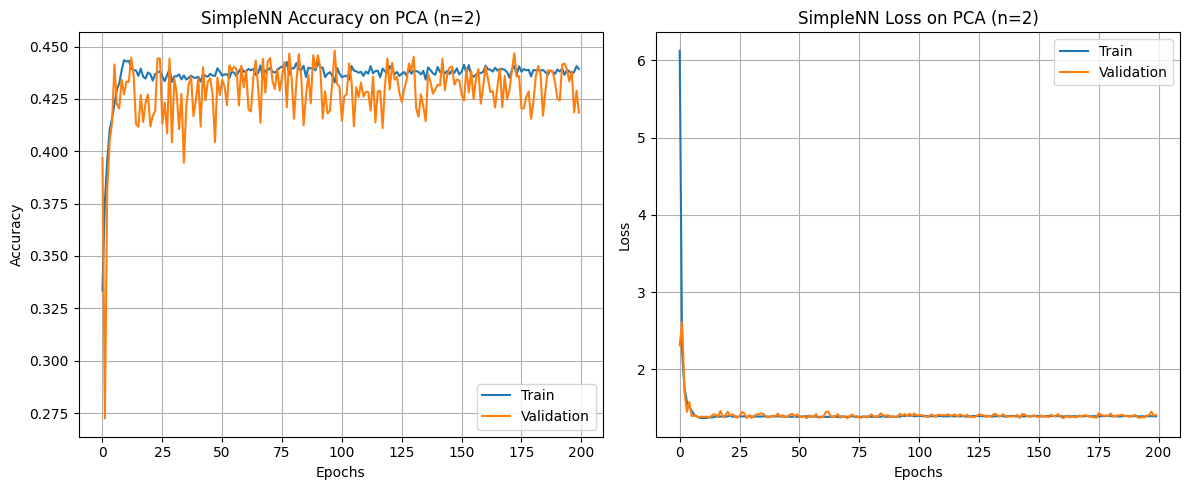

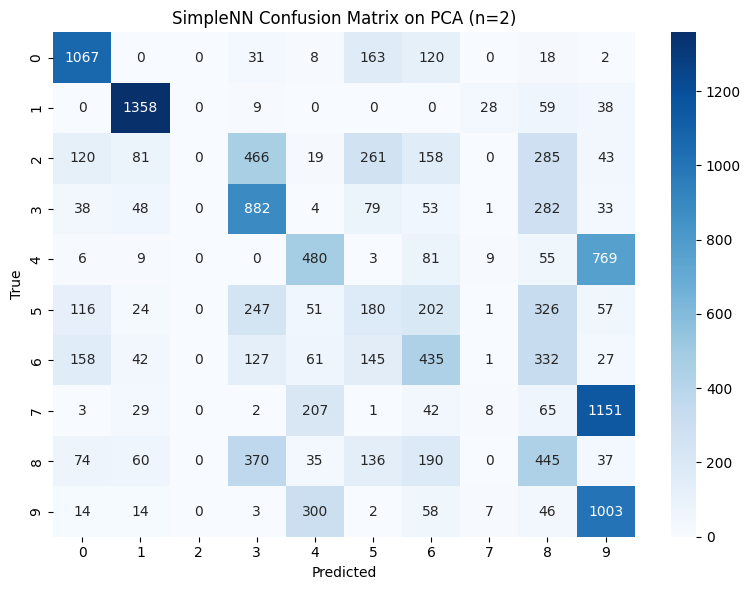

SimpleNN on PCA (n=2) - Test Accuracy: 0.4184

Training KNN classifier on PCA embeddings...
Training KNN on PCA (n=2)...


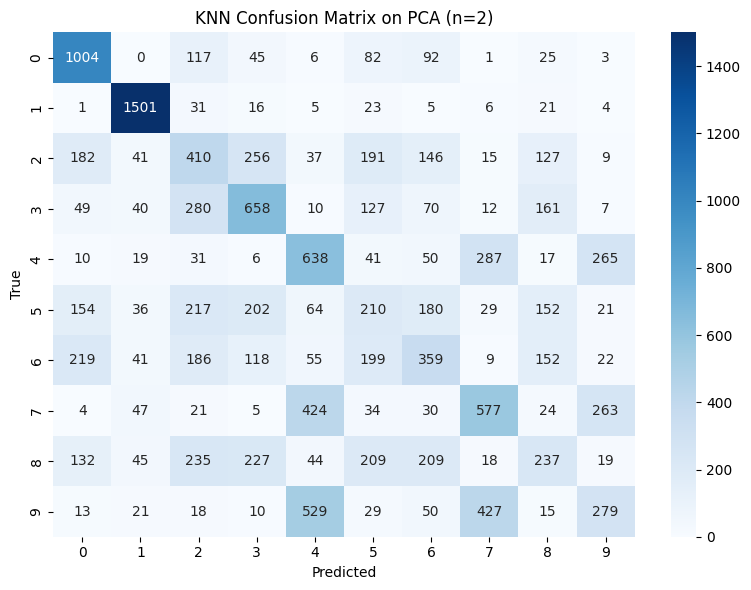

KNN on PCA (n=2) - Test Accuracy: 0.4195
KNN on PCA (n=2) - Test Accuracy: 0.4195


In [35]:
pca_metrics = evaluate_separation(pca_result, y_np)
print("\nPCA Separation Metrics:")
print(f"- Average inter-cluster distance: {pca_metrics['avg_inter_distance']:.4f}")
print(f"- Average intra-cluster distance: {pca_metrics['avg_intra_distance']:.4f}")
print(f"- Separation ratio: {pca_metrics['separation_ratio']:.4f}")

print("\nTraining SimpleNN classifier on PCA embeddings...")
pca_nn_model, pca_nn_acc, pca_nn_history, pca_nn_conf = train_nn_classifier(
    pca_result, y_np, n_components, f"PCA"
)
print(f"SimpleNN on PCA (n={n_components}) - Test Accuracy: {pca_nn_acc:.4f}")

print("\nTraining KNN classifier on PCA embeddings...")
pca_knn_model, pca_knn_acc, pca_knn_conf = train_knn_classifier(
    pca_result, y_np, n_components, f"PCA"
)
print(f"KNN on PCA (n={n_components}) - Test Accuracy: {pca_knn_acc:.4f}")

all_results.append({
    "Method": "PCA", 
    "n_components": n_components,
    "Explained_variance": sum(pca.explained_variance_ratio_),
    "Separation_ratio": pca_metrics['separation_ratio'],
    "SimpleNN_accuracy": pca_nn_acc,
    "KNN_accuracy": pca_knn_acc
})

#### Kernel PCA - Cosine


Performing Kernel PCA with cosine kernel, n_components=2...
Kernel PCA completed in 12.40 seconds


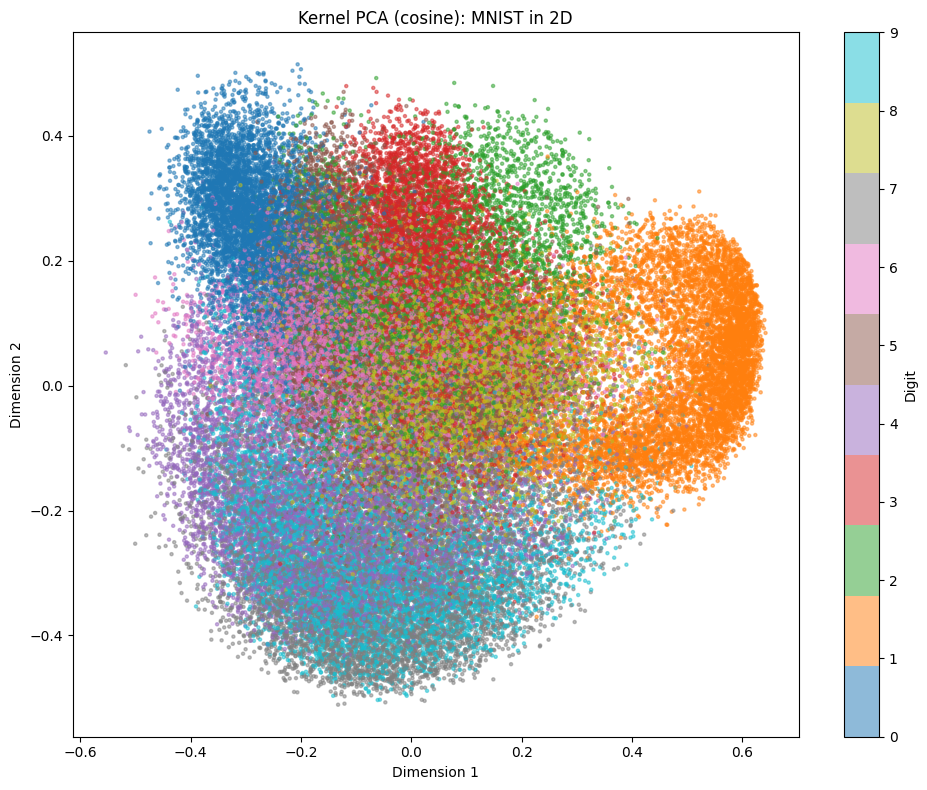

In [36]:
kernel = 'cosine'
print(f"\nPerforming Kernel PCA with {kernel} kernel, n_components={n_components}...")
start_time = time.time()
kpca = KernelPCA(n_components=n_components, kernel=kernel)
kpca_result = kpca.fit_transform(X_np)
print(f"Kernel PCA completed in {time.time() - start_time:.2f} seconds")

plot_embeddings(kpca_result, y_np, f"Kernel PCA ({kernel}): MNIST in {n_components}D")


Kernel PCA (cosine) Separation Metrics:
- Average inter-cluster distance: 0.3244
- Average intra-cluster distance: 0.1672
- Separation ratio: 1.9403

Training SimpleNN classifier on Kernel PCA (cosine) embeddings...


Training NN on KPCA_cosine (n=2):  26%|██▌       | 51/200 [00:07<00:23,  6.43it/s, loss=1.3153, acc=0.4756, val_acc=0.4681]

Epoch [50/200], Loss: 1.3151, Accuracy: 0.4747, Val Accuracy: 0.4746


Training NN on KPCA_cosine (n=2):  50%|█████     | 101/200 [00:15<00:15,  6.47it/s, loss=1.3033, acc=0.4789, val_acc=0.4680]

Epoch [100/200], Loss: 1.3024, Accuracy: 0.4775, Val Accuracy: 0.4733


Training NN on KPCA_cosine (n=2):  76%|███████▌  | 151/200 [00:23<00:07,  6.43it/s, loss=1.3009, acc=0.4784, val_acc=0.4770]

Epoch [150/200], Loss: 1.3021, Accuracy: 0.4794, Val Accuracy: 0.4760


Training NN on KPCA_cosine (n=2): 100%|██████████| 200/200 [00:30<00:00,  6.50it/s, loss=1.3004, acc=0.4788, val_acc=0.4783]


Epoch [200/200], Loss: 1.3004, Accuracy: 0.4788, Val Accuracy: 0.4783


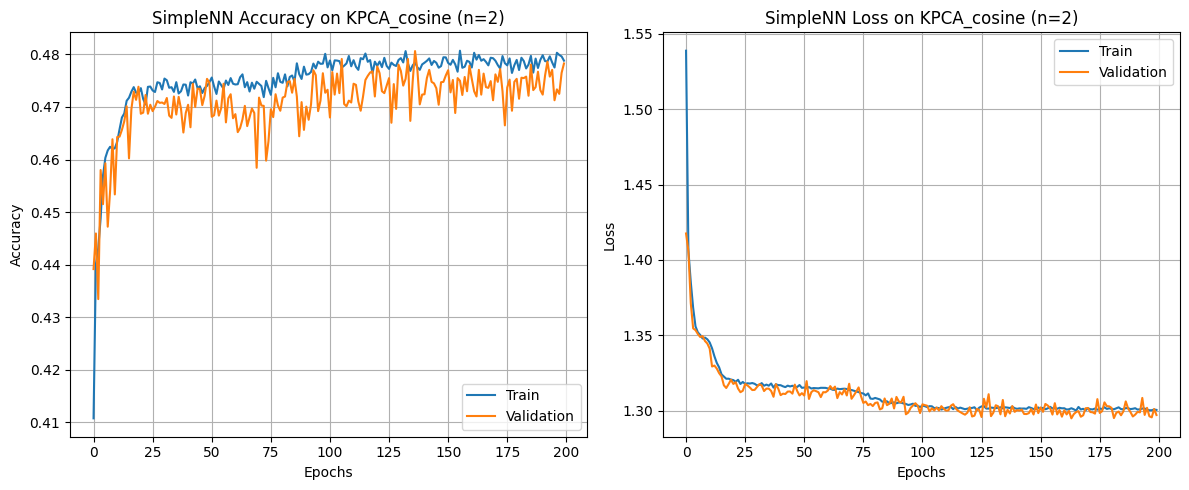

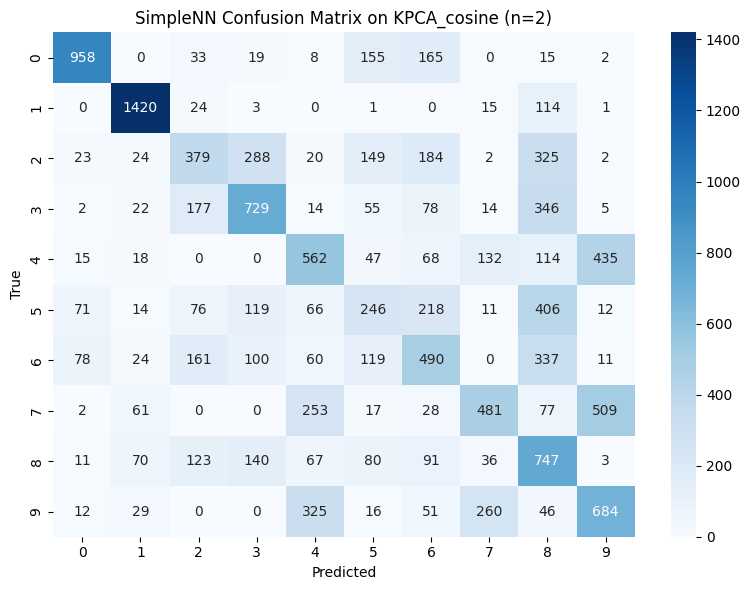

SimpleNN on KPCA_cosine (n=2) - Test Accuracy: 0.4783

Training KNN classifier on Kernel PCA (cosine) embeddings...
Training KNN on KPCA_cosine (n=2)...


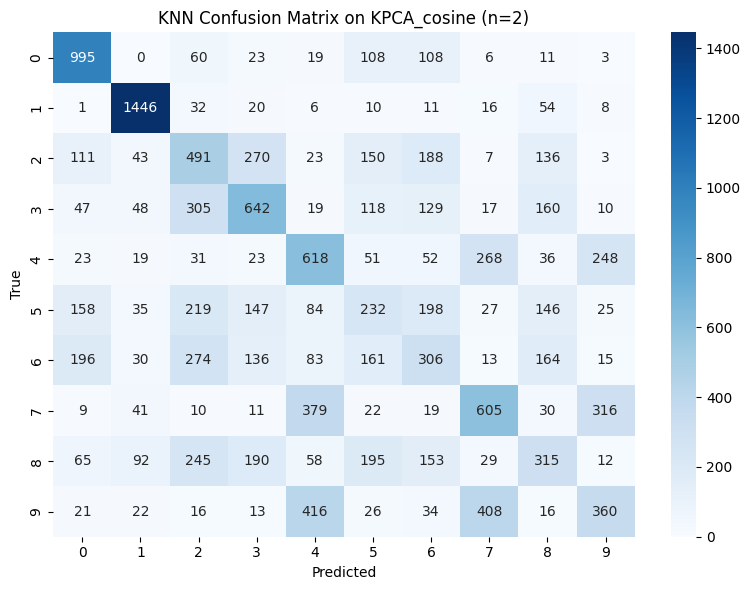

KNN on KPCA_cosine (n=2) - Test Accuracy: 0.4293
KNN on KPCA_cosine (n=2) - Test Accuracy: 0.4293


In [37]:
kpca_metrics = evaluate_separation(kpca_result, y_np)
print(f"\nKernel PCA ({kernel}) Separation Metrics:")
print(f"- Average inter-cluster distance: {kpca_metrics['avg_inter_distance']:.4f}")
print(f"- Average intra-cluster distance: {kpca_metrics['avg_intra_distance']:.4f}")
print(f"- Separation ratio: {kpca_metrics['separation_ratio']:.4f}")

print(f"\nTraining SimpleNN classifier on Kernel PCA ({kernel}) embeddings...")
kpca_nn_model, kpca_nn_acc, kpca_nn_history, kpca_nn_conf = train_nn_classifier(
    kpca_result, y_np, n_components, f"KPCA_{kernel}"
)
print(f"SimpleNN on KPCA_{kernel} (n={n_components}) - Test Accuracy: {kpca_nn_acc:.4f}")

print(f"\nTraining KNN classifier on Kernel PCA ({kernel}) embeddings...")
kpca_knn_model, kpca_knn_acc, kpca_knn_conf = train_knn_classifier(
    kpca_result, y_np, n_components, f"KPCA_{kernel}"
)
print(f"KNN on KPCA_{kernel} (n={n_components}) - Test Accuracy: {kpca_knn_acc:.4f}")

all_results.append({
    "Method": f"KernelPCA_{kernel}", 
    "n_components": n_components,
    "Explained_variance": "N/A",
    "Separation_ratio": kpca_metrics['separation_ratio'],
    "SimpleNN_accuracy": kpca_nn_acc,
    "KNN_accuracy": kpca_knn_acc
})

#### t-SNE


Performing t-SNE with n_components=2, perplexity=30...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 70000 samples in 0.006s...
[t-SNE] Computed neighbors for 70000 samples in 11.112s...
[t-SNE] Computed conditional probabilities for sample 1000 / 70000
[t-SNE] Computed conditional probabilities for sample 2000 / 70000
[t-SNE] Computed conditional probabilities for sample 3000 / 70000
[t-SNE] Computed conditional probabilities for sample 4000 / 70000
[t-SNE] Computed conditional probabilities for sample 5000 / 70000
[t-SNE] Computed conditional probabilities for sample 6000 / 70000
[t-SNE] Computed conditional probabilities for sample 7000 / 70000
[t-SNE] Computed conditional probabilities for sample 8000 / 70000
[t-SNE] Computed conditional probabilities for sample 9000 / 70000
[t-SNE] Computed conditional probabilities for sample 10000 / 70000
[t-SNE] Computed conditional probabilities for sample 11000 / 70000
[t-SNE] Computed conditional probabilities for sample 12000 /

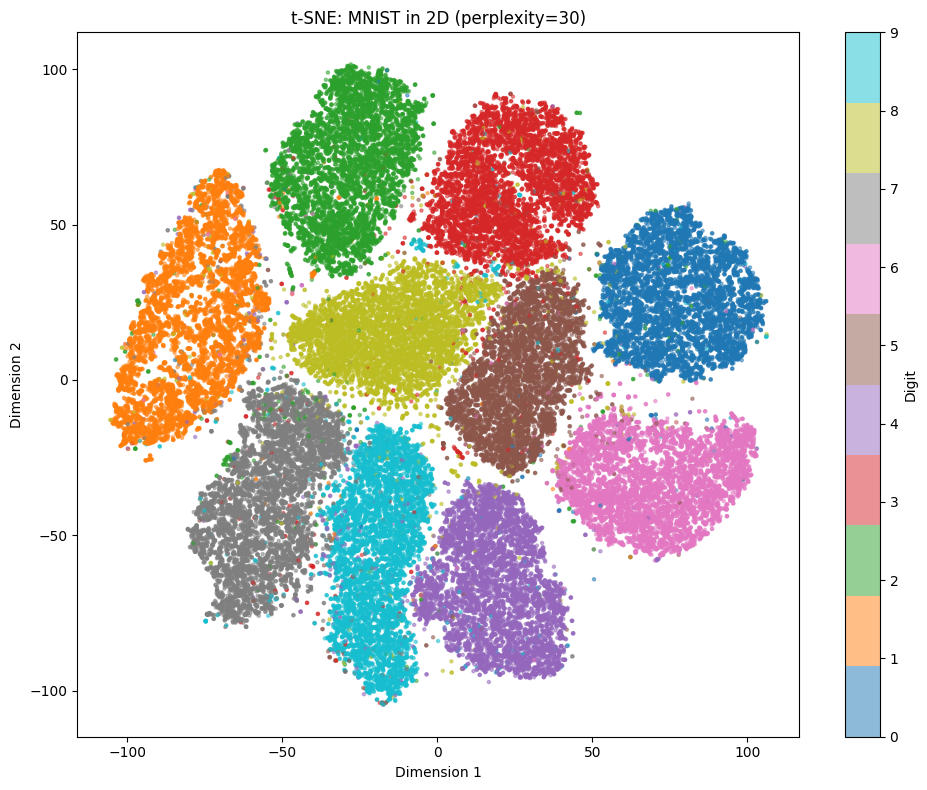

In [38]:
perplexity = 30
print(f"\nPerforming t-SNE with n_components={n_components}, perplexity={perplexity}...")
start_time = time.time()
tsne = TSNE(n_components=n_components, perplexity=perplexity, n_iter=1000, verbose=1, random_state=42)
tsne_result = tsne.fit_transform(X_np)
print(f"t-SNE completed in {time.time() - start_time:.2f} seconds")

plot_embeddings(tsne_result, y_np, f"t-SNE: MNIST in {n_components}D (perplexity={perplexity})")


t-SNE Separation Metrics:
- Average inter-cluster distance: 89.9592
- Average intra-cluster distance: 21.2035
- Separation ratio: 4.2427

Training SimpleNN classifier on t-SNE embeddings...


Training NN on t-SNE (n=2):  26%|██▌       | 51/200 [00:07<00:22,  6.52it/s, loss=0.2364, acc=0.9602, val_acc=0.9606]

Epoch [50/200], Loss: 0.2370, Accuracy: 0.9595, Val Accuracy: 0.9624


Training NN on t-SNE (n=2):  50%|█████     | 101/200 [00:15<00:15,  6.49it/s, loss=0.2364, acc=0.9613, val_acc=0.9596]

Epoch [100/200], Loss: 0.2357, Accuracy: 0.9602, Val Accuracy: 0.9635


Training NN on t-SNE (n=2):  76%|███████▌  | 151/200 [00:23<00:07,  6.48it/s, loss=0.2375, acc=0.9602, val_acc=0.9576]

Epoch [150/200], Loss: 0.2354, Accuracy: 0.9598, Val Accuracy: 0.9628


Training NN on t-SNE (n=2): 100%|██████████| 200/200 [00:30<00:00,  6.50it/s, loss=0.2343, acc=0.9609, val_acc=0.9626]


Epoch [200/200], Loss: 0.2343, Accuracy: 0.9609, Val Accuracy: 0.9626


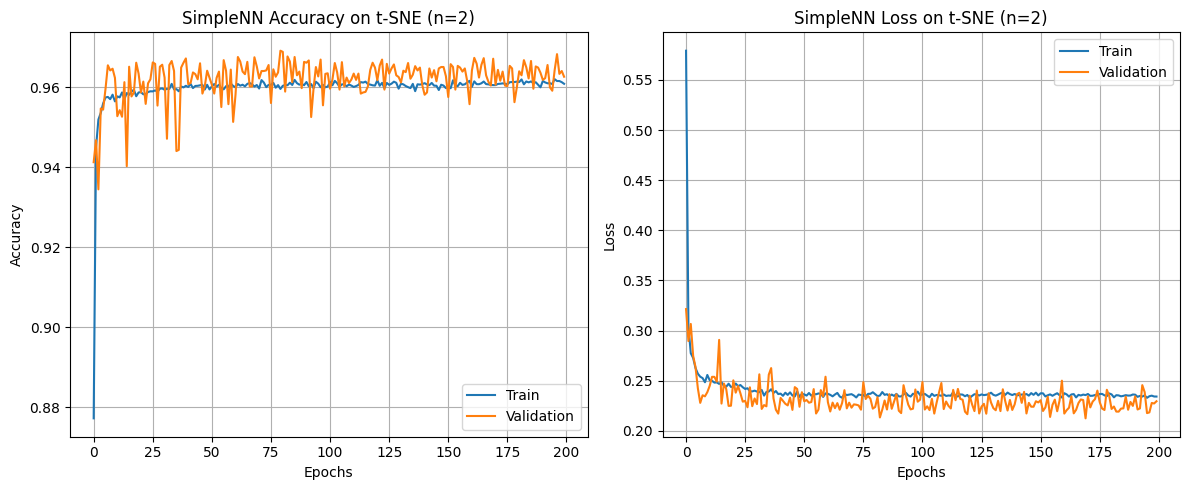

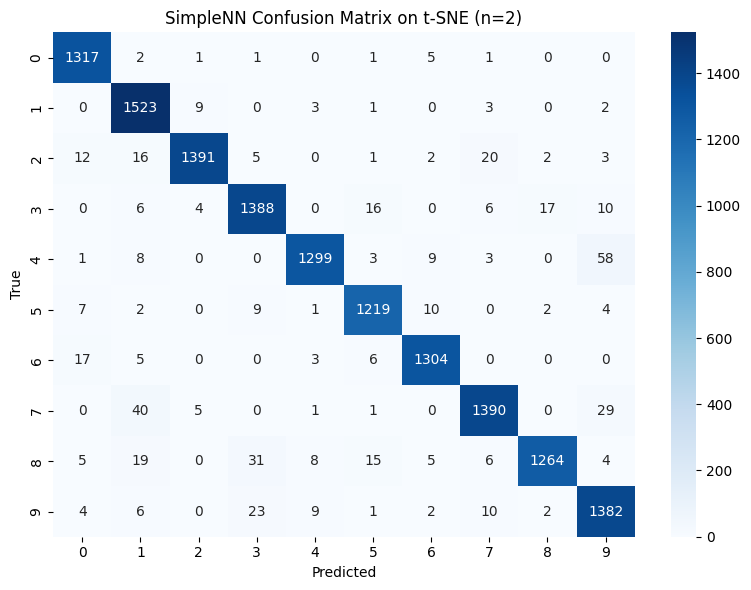

SimpleNN on t-SNE (n=2) - Test Accuracy: 0.9626

Training KNN classifier on t-SNE embeddings...
Training KNN on t-SNE (n=2)...


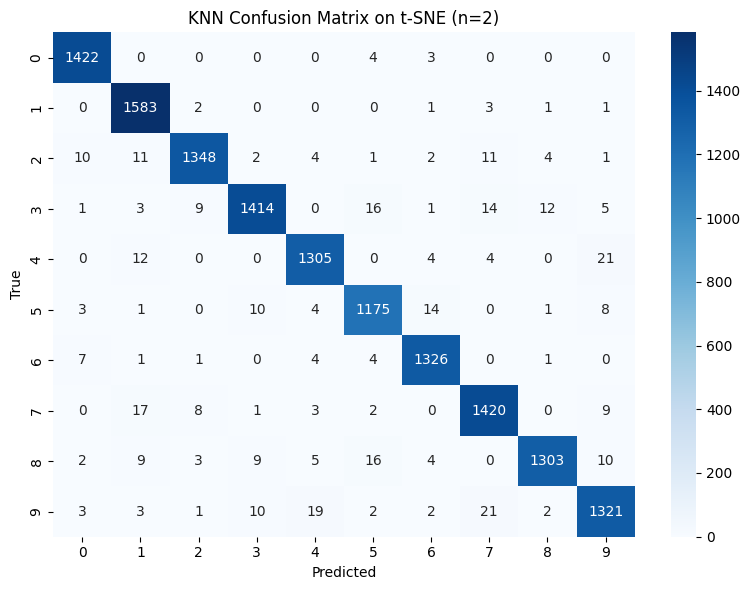

KNN on t-SNE (n=2) - Test Accuracy: 0.9726
KNN on t-SNE (n=2) - Test Accuracy: 0.9726


In [39]:
tsne_metrics = evaluate_separation(tsne_result, y_np)
print("\nt-SNE Separation Metrics:")
print(f"- Average inter-cluster distance: {tsne_metrics['avg_inter_distance']:.4f}")
print(f"- Average intra-cluster distance: {tsne_metrics['avg_intra_distance']:.4f}")
print(f"- Separation ratio: {tsne_metrics['separation_ratio']:.4f}")

print("\nTraining SimpleNN classifier on t-SNE embeddings...")
tsne_nn_model, tsne_nn_acc, tsne_nn_history, tsne_nn_conf = train_nn_classifier(
    tsne_result, y_np, n_components, "t-SNE"
)
print(f"SimpleNN on t-SNE (n={n_components}) - Test Accuracy: {tsne_nn_acc:.4f}")

print("\nTraining KNN classifier on t-SNE embeddings...")
tsne_knn_model, tsne_knn_acc, tsne_knn_conf = train_knn_classifier(
    tsne_result, y_np, n_components, "t-SNE"
)
print(f"KNN on t-SNE (n={n_components}) - Test Accuracy: {tsne_knn_acc:.4f}")

all_results.append({
    "Method": "t-SNE", 
    "n_components": n_components,
    "Explained_variance": "N/A",
    "Separation_ratio": tsne_metrics['separation_ratio'],
    "SimpleNN_accuracy": tsne_nn_acc,
    "KNN_accuracy": tsne_knn_acc
})

PCA (n=2) - Average reconstruction MSE: 3635.5264


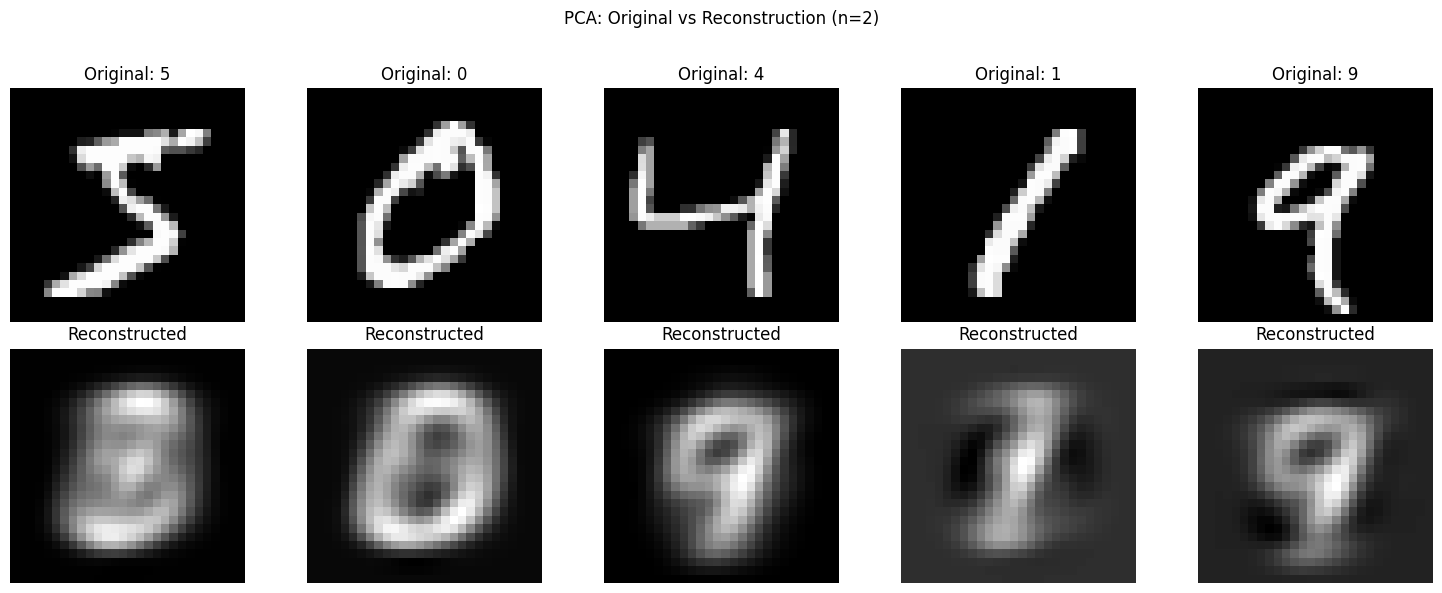

In [ ]:
X_reconstructed_pca2 = pca.inverse_transform(pca_result)

pca2_mse = np.mean((X_np - X_reconstructed_pca2) ** 2)
print(f"PCA (n=2) - Average reconstruction MSE: {pca2_mse:.4f}")

visualize_reconstruction(X_np, X_reconstructed_pca2, y_np, 
                         title=f'PCA: Original vs Reconstruction (n={n_components})')

### `n_components = 3`

In [41]:
n_components = 3

#### PCA


Performing PCA with n_components=3...
PCA completed in 0.07 seconds
Explained variance ratio (first 5 components): [0.09746247 0.07155529 0.06149633]
Total explained variance: 0.2305


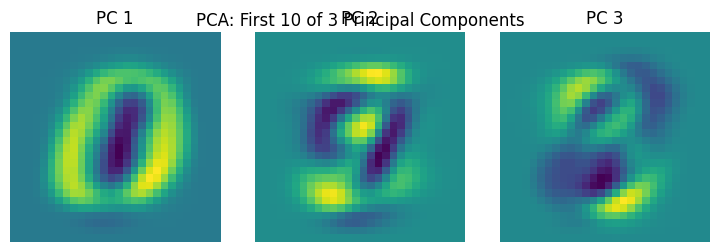

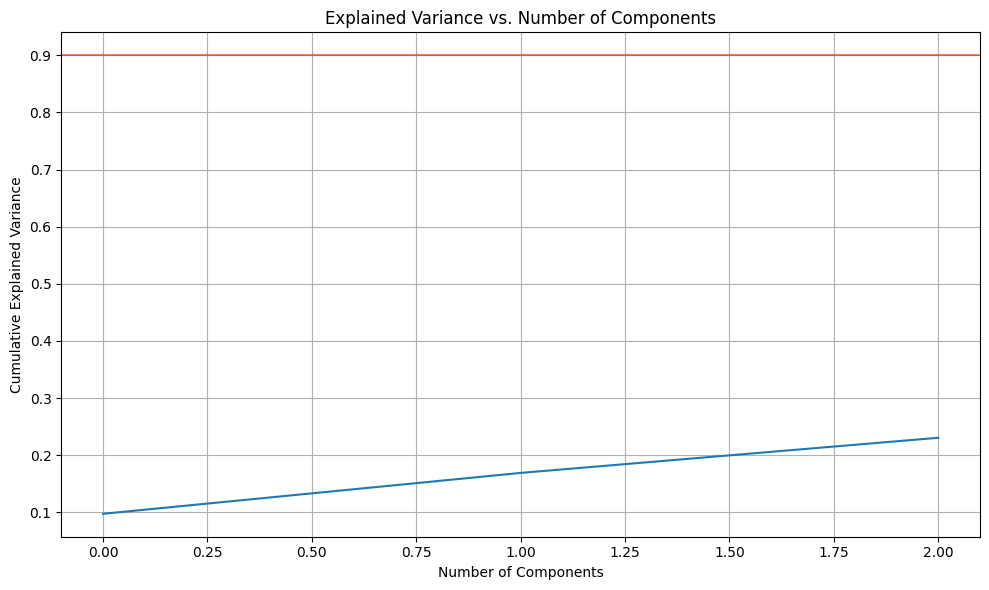


Training SimpleNN classifier on PCA embeddings...


Training NN on PCA (n=3):  26%|██▌       | 51/200 [00:07<00:23,  6.38it/s, loss=1.3021, acc=0.4752, val_acc=0.4728]

Epoch [50/200], Loss: 1.3059, Accuracy: 0.4727, Val Accuracy: 0.4889


Training NN on PCA (n=3):  50%|█████     | 101/200 [00:15<00:15,  6.39it/s, loss=1.3060, acc=0.4699, val_acc=0.4533]

Epoch [100/200], Loss: 1.3039, Accuracy: 0.4688, Val Accuracy: 0.4858


Training NN on PCA (n=3):  76%|███████▌  | 151/200 [00:23<00:07,  6.57it/s, loss=1.3056, acc=0.4721, val_acc=0.4426]

Epoch [150/200], Loss: 1.3002, Accuracy: 0.4721, Val Accuracy: 0.4711


Training NN on PCA (n=3): 100%|██████████| 200/200 [00:31<00:00,  6.42it/s, loss=1.3014, acc=0.4747, val_acc=0.4789]


Epoch [200/200], Loss: 1.3014, Accuracy: 0.4747, Val Accuracy: 0.4789


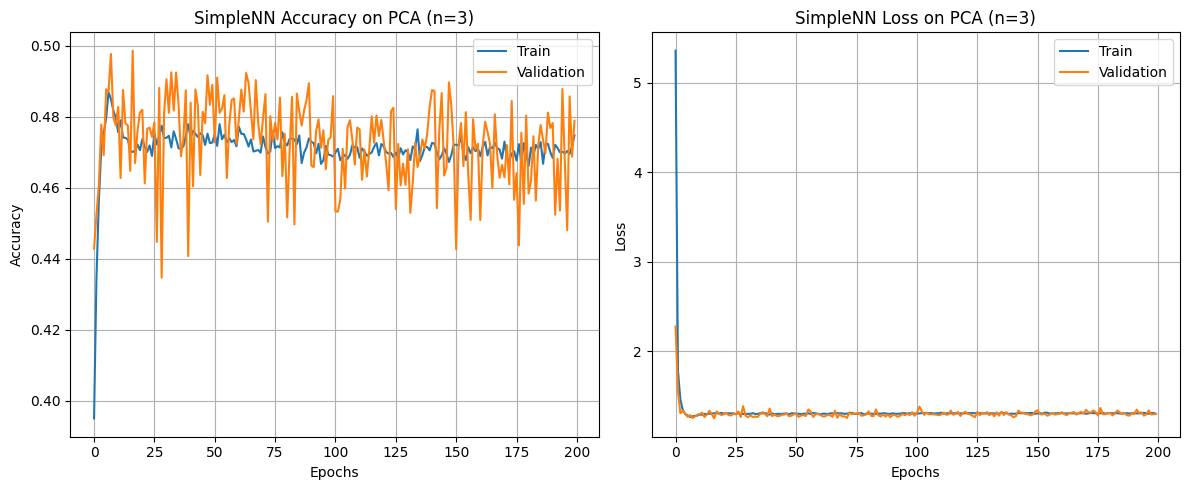

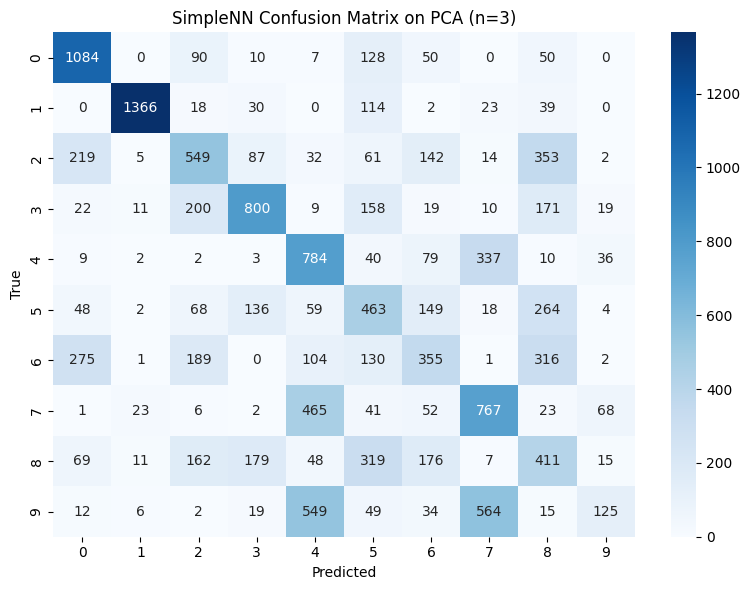

SimpleNN on PCA (n=3) - Test Accuracy: 0.4789

Training KNN classifier on PCA embeddings...
Training KNN on PCA (n=3)...


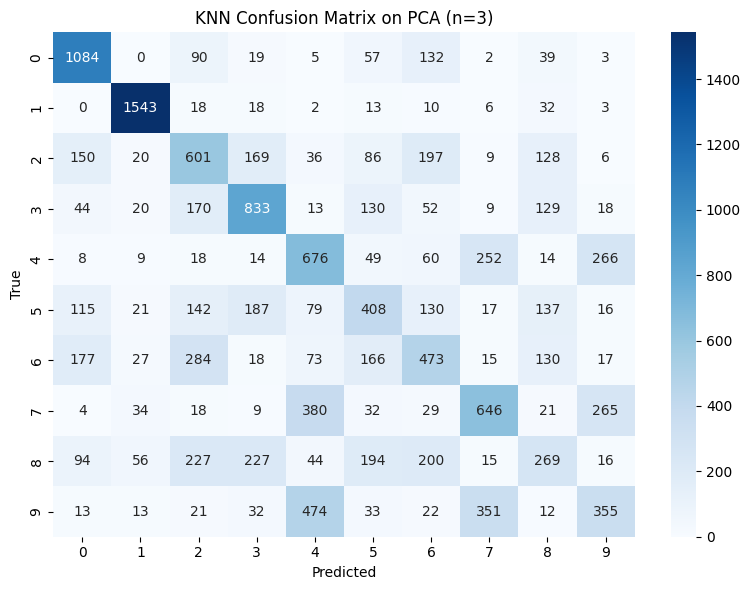

KNN on PCA (n=3) - Test Accuracy: 0.4920
KNN on PCA (n=3) - Test Accuracy: 0.4920


In [42]:
print(f"\nPerforming PCA with n_components={n_components}...")
start_time = time.time()
pca = PCA(n_components=n_components)
pca_result = pca.fit_transform(X_np)
print(f"PCA completed in {time.time() - start_time:.2f} seconds")
print(f"Explained variance ratio (first 5 components): {pca.explained_variance_ratio_[:5]}")
print(f"Total explained variance: {sum(pca.explained_variance_ratio_):.4f}")

visualize_components(pca.components_, f"PCA: First 10 of {n_components} Principal Components", n_to_show=10)

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.axhline(y=0.9, color='r', linestyle='-', alpha=0.5)
plt.grid(True)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.tight_layout()
plt.savefig(f"../result/PCA_explained_variance_n{n_components}.png")
plt.show()

print("\nTraining SimpleNN classifier on PCA embeddings...")
pca_nn_model, pca_nn_acc, pca_nn_history, pca_nn_conf = train_nn_classifier(
    pca_result, y_np, n_components, f"PCA"
)
print(f"SimpleNN on PCA (n={n_components}) - Test Accuracy: {pca_nn_acc:.4f}")

print("\nTraining KNN classifier on PCA embeddings...")
pca_knn_model, pca_knn_acc, pca_knn_conf = train_knn_classifier(
    pca_result, y_np, n_components, f"PCA"
)
print(f"KNN on PCA (n={n_components}) - Test Accuracy: {pca_knn_acc:.4f}")

all_results.append({
    "Method": "PCA", 
    "n_components": n_components,
    "Explained_variance": sum(pca.explained_variance_ratio_),
    "Separation_ratio": "N/A",
    "SimpleNN_accuracy": pca_nn_acc,
    "KNN_accuracy": pca_knn_acc
})

#### Kernel PCA - Cosine


Performing Kernel PCA with cosine kernel, n_components=3...
Kernel PCA completed in 26.40 seconds

Training SimpleNN classifier on Kernel PCA (cosine) embeddings...


Training NN on KPCA_cosine (n=3):  26%|██▌       | 51/200 [00:07<00:23,  6.42it/s, loss=1.0762, acc=0.5710, val_acc=0.5679]

Epoch [50/200], Loss: 1.0764, Accuracy: 0.5713, Val Accuracy: 0.5629


Training NN on KPCA_cosine (n=3):  50%|█████     | 101/200 [00:15<00:15,  6.42it/s, loss=1.0650, acc=0.5757, val_acc=0.5670]

Epoch [100/200], Loss: 1.0652, Accuracy: 0.5739, Val Accuracy: 0.5671


Training NN on KPCA_cosine (n=3):  76%|███████▌  | 151/200 [00:23<00:07,  6.39it/s, loss=1.0622, acc=0.5749, val_acc=0.5676]

Epoch [150/200], Loss: 1.0625, Accuracy: 0.5737, Val Accuracy: 0.5655


Training NN on KPCA_cosine (n=3): 100%|██████████| 200/200 [00:31<00:00,  6.44it/s, loss=1.0616, acc=0.5742, val_acc=0.5679]


Epoch [200/200], Loss: 1.0616, Accuracy: 0.5742, Val Accuracy: 0.5679


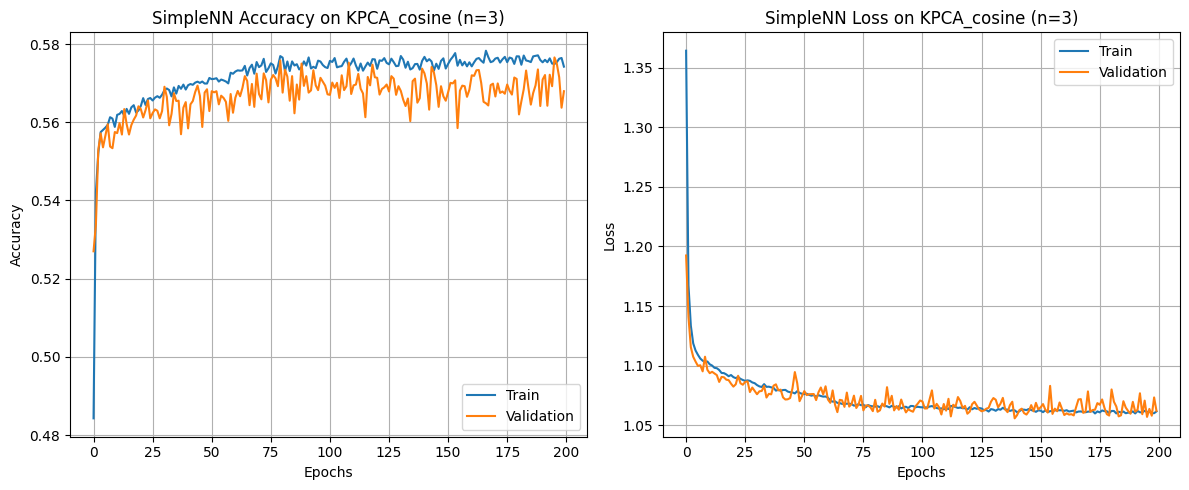

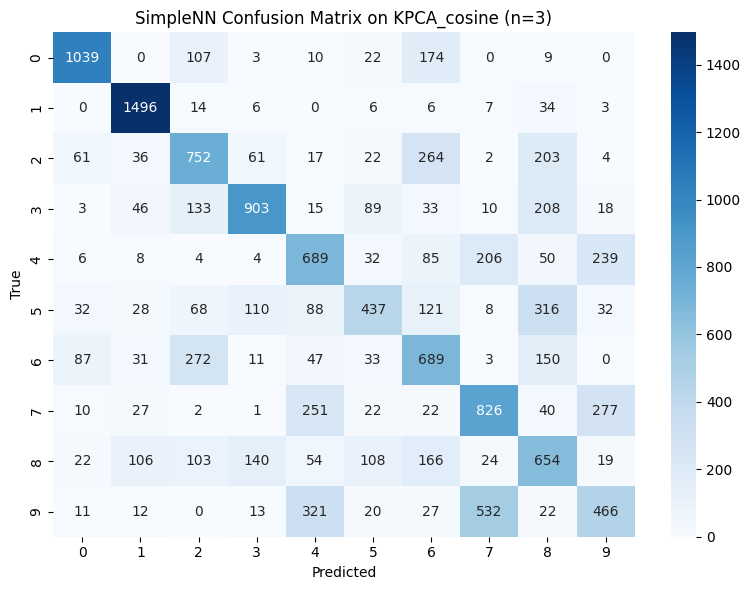

SimpleNN on KPCA_cosine (n=3) - Test Accuracy: 0.5679

Training KNN classifier on Kernel PCA (cosine) embeddings...
Training KNN on KPCA_cosine (n=3)...


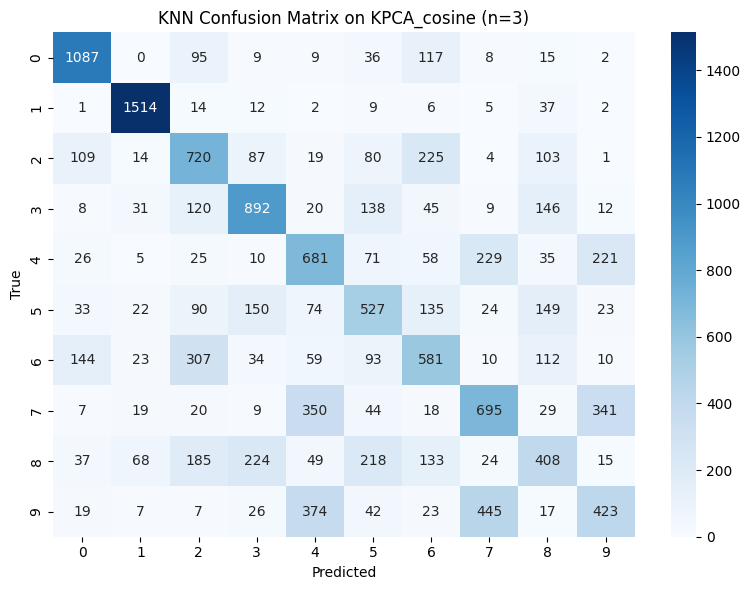

KNN on KPCA_cosine (n=3) - Test Accuracy: 0.5377
KNN on KPCA_cosine (n=3) - Test Accuracy: 0.5377


In [43]:
kernel = 'cosine'
gamma = 0.01
print(f"\nPerforming Kernel PCA with {kernel} kernel, n_components={n_components}...")
start_time = time.time()
kpca = KernelPCA(n_components=n_components, kernel=kernel, n_jobs=-1)
kpca_result = kpca.fit_transform(X_np)
print(f"Kernel PCA completed in {time.time() - start_time:.2f} seconds")

print(f"\nTraining SimpleNN classifier on Kernel PCA ({kernel}) embeddings...")
kpca_nn_model, kpca_nn_acc, kpca_nn_history, kpca_nn_conf = train_nn_classifier(
    kpca_result, y_np, n_components, f"KPCA_{kernel}"
)
print(f"SimpleNN on KPCA_{kernel} (n={n_components}) - Test Accuracy: {kpca_nn_acc:.4f}")

print(f"\nTraining KNN classifier on Kernel PCA ({kernel}) embeddings...")
kpca_knn_model, kpca_knn_acc, kpca_knn_conf = train_knn_classifier(
    kpca_result, y_np, n_components, f"KPCA_{kernel}"
)
print(f"KNN on KPCA_{kernel} (n={n_components}) - Test Accuracy: {kpca_knn_acc:.4f}")

all_results.append({
    "Method": f"KernelPCA_{kernel}", 
    "n_components": n_components,
    "Explained_variance": "N/A",
    "Separation_ratio": "N/A",
    "SimpleNN_accuracy": kpca_nn_acc,
    "KNN_accuracy": kpca_knn_acc
})

#### t-SNE


Performing t-SNE with n_components=3, perplexity=30...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 70000 samples in 0.006s...
[t-SNE] Computed neighbors for 70000 samples in 11.119s...
[t-SNE] Computed conditional probabilities for sample 1000 / 70000
[t-SNE] Computed conditional probabilities for sample 2000 / 70000
[t-SNE] Computed conditional probabilities for sample 3000 / 70000
[t-SNE] Computed conditional probabilities for sample 4000 / 70000
[t-SNE] Computed conditional probabilities for sample 5000 / 70000
[t-SNE] Computed conditional probabilities for sample 6000 / 70000
[t-SNE] Computed conditional probabilities for sample 7000 / 70000
[t-SNE] Computed conditional probabilities for sample 8000 / 70000
[t-SNE] Computed conditional probabilities for sample 9000 / 70000
[t-SNE] Computed conditional probabilities for sample 10000 / 70000
[t-SNE] Computed conditional probabilities for sample 11000 / 70000
[t-SNE] Computed conditional probabilities for sample 12000 /

Training NN on t-SNE (n=3):  26%|██▌       | 51/200 [00:07<00:23,  6.44it/s, loss=0.1997, acc=0.9647, val_acc=0.9709]

Epoch [50/200], Loss: 0.2017, Accuracy: 0.9642, Val Accuracy: 0.9653


Training NN on t-SNE (n=3):  50%|█████     | 101/200 [00:15<00:15,  6.51it/s, loss=0.2005, acc=0.9649, val_acc=0.9679]

Epoch [100/200], Loss: 0.1995, Accuracy: 0.9643, Val Accuracy: 0.9690


Training NN on t-SNE (n=3):  76%|███████▌  | 151/200 [00:23<00:07,  6.54it/s, loss=0.1991, acc=0.9651, val_acc=0.9678]

Epoch [150/200], Loss: 0.1971, Accuracy: 0.9655, Val Accuracy: 0.9702


Training NN on t-SNE (n=3): 100%|██████████| 200/200 [00:30<00:00,  6.46it/s, loss=0.1996, acc=0.9649, val_acc=0.9671]


Epoch [200/200], Loss: 0.1996, Accuracy: 0.9649, Val Accuracy: 0.9671


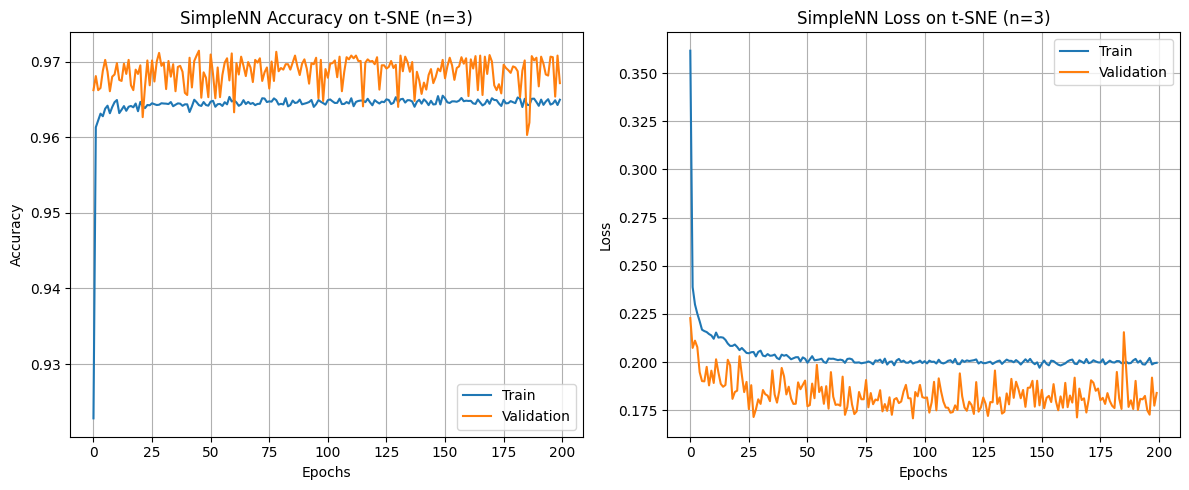

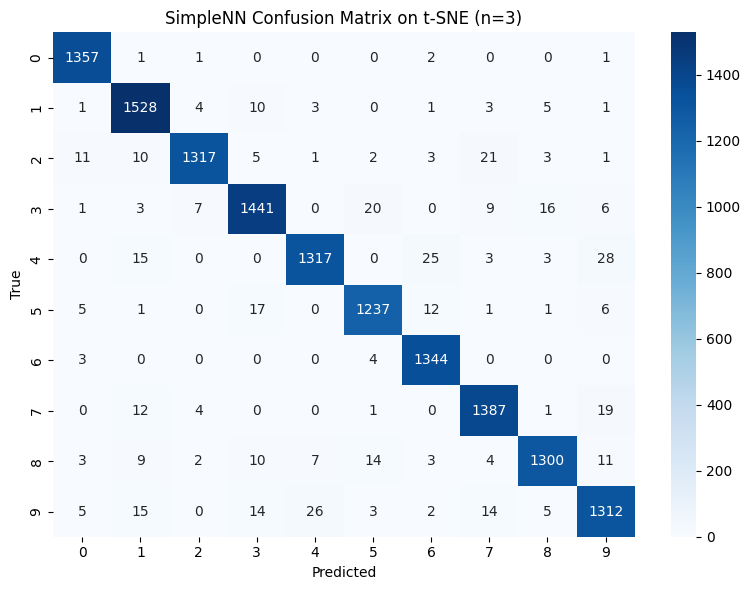

SimpleNN on t-SNE (n=3) - Test Accuracy: 0.9671

Training KNN classifier on t-SNE embeddings...
Training KNN on t-SNE (n=3)...


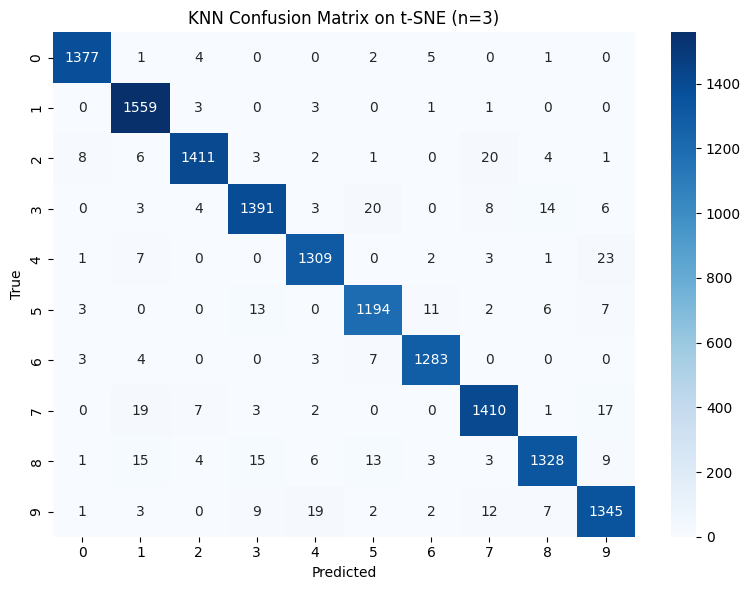

KNN on t-SNE (n=3) - Test Accuracy: 0.9719
KNN on t-SNE (n=3) - Test Accuracy: 0.9719


In [44]:
perplexity = 30
print(f"\nPerforming t-SNE with n_components={n_components}, perplexity={perplexity}...")
start_time = time.time()
tsne = TSNE(n_components=3, perplexity=perplexity, n_iter=1000, verbose=1, random_state=42)
tsne_result = tsne.fit_transform(X_np)
print(f"t-SNE completed in {time.time() - start_time:.2f} seconds")

print("\nTraining SimpleNN classifier on t-SNE embeddings...")
tsne_nn_model, tsne_nn_acc, tsne_nn_history, tsne_nn_conf = train_nn_classifier(
    tsne_result, y_np, n_components, "t-SNE"
)
print(f"SimpleNN on t-SNE (n={n_components}) - Test Accuracy: {tsne_nn_acc:.4f}")

print("\nTraining KNN classifier on t-SNE embeddings...")
tsne_knn_model, tsne_knn_acc, tsne_knn_conf = train_knn_classifier(
    tsne_result, y_np, n_components, "t-SNE"
)
print(f"KNN on t-SNE (n={n_components}) - Test Accuracy: {tsne_knn_acc:.4f}")

all_results.append({
    "Method": "t-SNE", 
    "n_components": n_components,
    "Explained_variance": "N/A",
    "Separation_ratio": "N/A",
    "SimpleNN_accuracy": tsne_nn_acc,
    "KNN_accuracy": tsne_knn_acc
})

PCA (n=30) - Average reconstruction MSE: 3366.4856


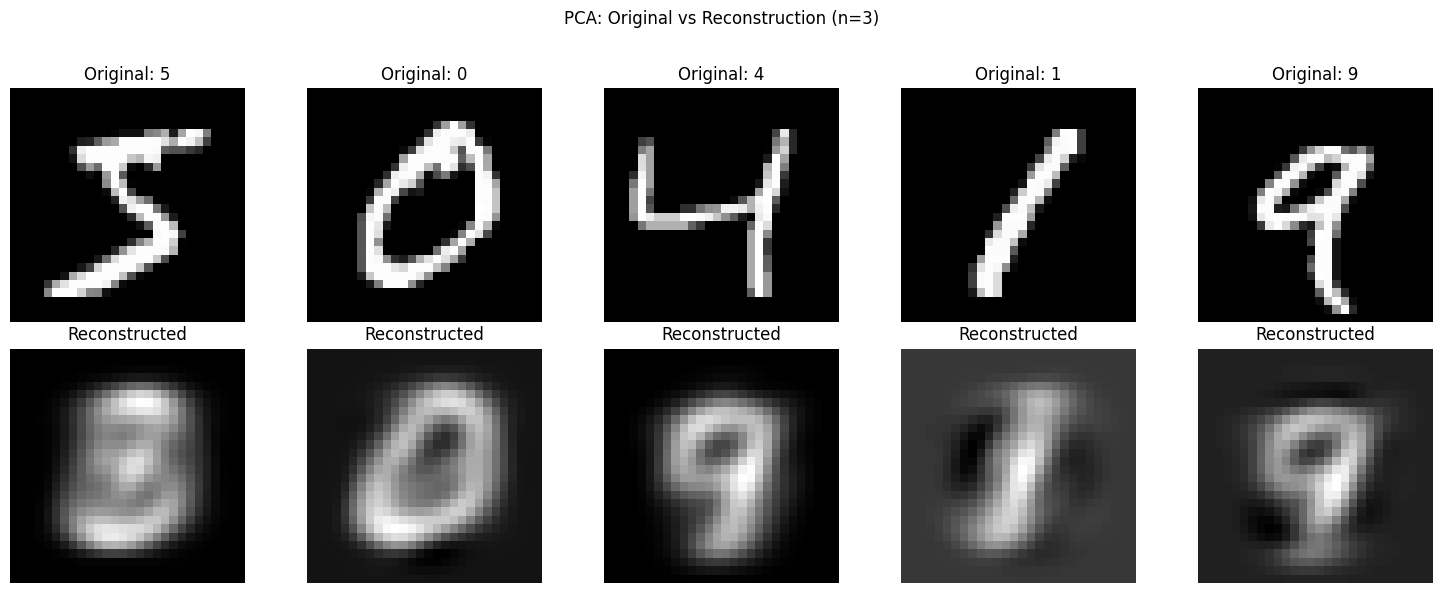

In [45]:
X_reconstructed_pca30 = pca.inverse_transform(pca_result)

pca30_mse = np.mean((X_np - X_reconstructed_pca30) ** 2)
print(f"PCA (n=30) - Average reconstruction MSE: {pca30_mse:.4f}")

visualize_reconstruction(X_np, X_reconstructed_pca30, y_np,
                         title=f'PCA: Original vs Reconstruction (n={n_components})')

### `n_components = 784`

In [46]:
n_components = 784



===== Running experiments with original dimensionality (n_components = 784) =====


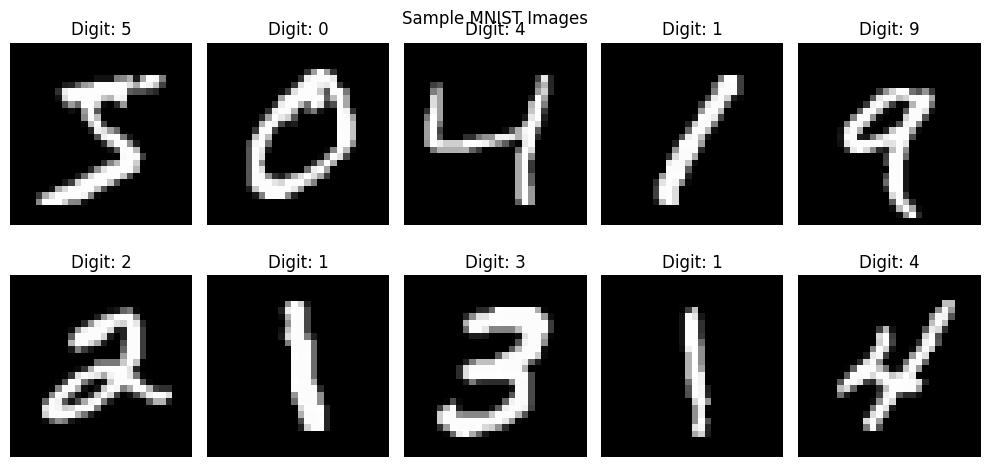


Training SimpleNN classifier on original data...


Training NN on Original (n=784):  25%|██▌       | 25/100 [00:09<00:28,  2.68it/s, loss=0.0651, acc=0.9841, val_acc=0.9651]

Epoch [25/100], Loss: 0.0651, Accuracy: 0.9841, Val Accuracy: 0.9651


Training NN on Original (n=784):  50%|█████     | 50/100 [00:18<00:18,  2.63it/s, loss=0.0583, acc=0.9894, val_acc=0.9656]

Epoch [50/100], Loss: 0.0583, Accuracy: 0.9894, Val Accuracy: 0.9656


Training NN on Original (n=784):  75%|███████▌  | 75/100 [00:28<00:09,  2.63it/s, loss=0.0436, acc=0.9934, val_acc=0.9671]

Epoch [75/100], Loss: 0.0436, Accuracy: 0.9934, Val Accuracy: 0.9671


Training NN on Original (n=784): 100%|██████████| 100/100 [00:37<00:00,  2.63it/s, loss=0.0292, acc=0.9956, val_acc=0.9669]

Epoch [100/100], Loss: 0.0292, Accuracy: 0.9956, Val Accuracy: 0.9669


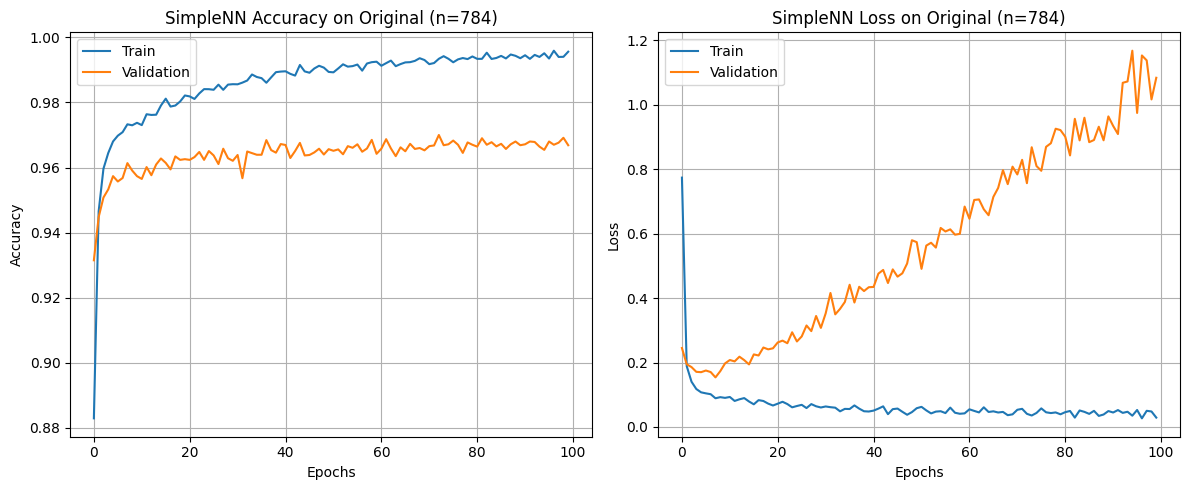

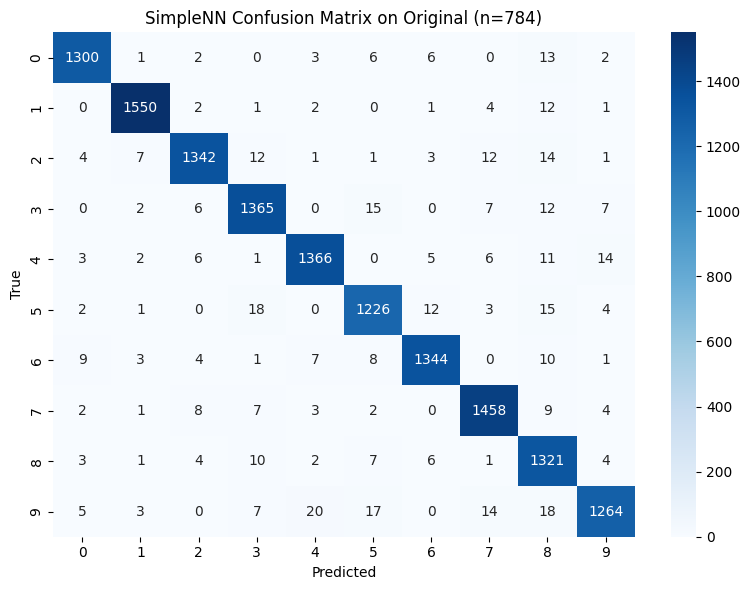

SimpleNN training completed in 38.28 seconds
SimpleNN on Original data (n=784) - Test Accuracy: 0.9669

Training KNN classifier on original data... (this might take a while)
Training KNN on Original (n=784)...


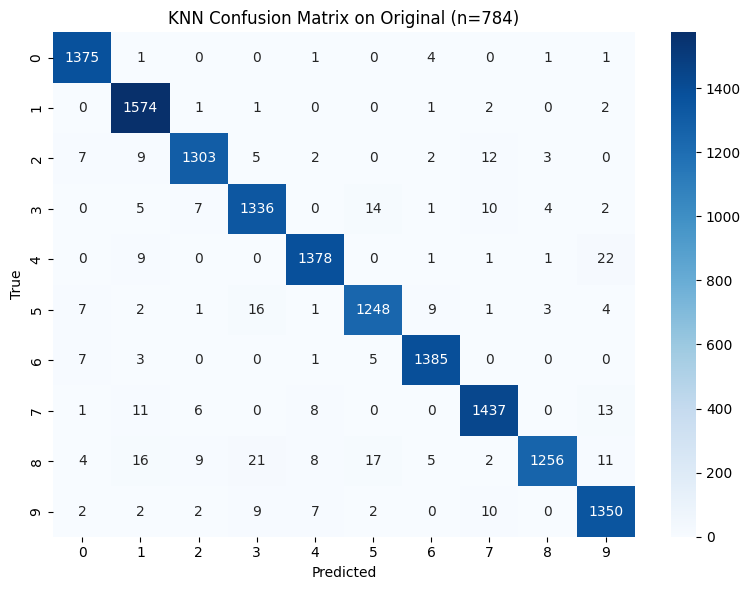

KNN on Original (n=784) - Test Accuracy: 0.9744
KNN training completed in 2.35 seconds
KNN on Original data (n=784) - Test Accuracy: 0.9744


In [ ]:
print("\n\n===== Running experiments with original dimensionality (n_components = 784) =====")

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_np[i].reshape(28, 28), cmap='gray')
    plt.title(f"Digit: {y_np[i]}")
    plt.axis('off')
plt.tight_layout()
plt.suptitle("Sample MNIST Images")
plt.savefig(f"../result/MNIST_sample_images.png")
plt.show()

print("\nTraining SimpleNN classifier on original data...")
start_time = time.time()
original_nn_model, original_nn_acc, original_nn_history, original_nn_conf = train_nn_classifier(
    X_np, y_np, n_components, "Original"
)
print(f"SimpleNN training completed in {time.time() - start_time:.2f} seconds")
print(f"SimpleNN on Original data (n={n_components}) - Test Accuracy: {original_nn_acc:.4f}")

print("\nTraining KNN classifier on original data... (this might take a while)")
start_time = time.time()
original_knn_model, original_knn_acc, original_knn_conf = train_knn_classifier(
    X_np, y_np, n_components, "Original"
)
print(f"KNN training completed in {time.time() - start_time:.2f} seconds")
print(f"KNN on Original data (n={n_components}) - Test Accuracy: {original_knn_acc:.4f}")

all_results.append({
    "Method": "Original", 
    "n_components": n_components,
    "Explained_variance": 1.0,
    "Separation_ratio": "N/A",
    "SimpleNN_accuracy": original_nn_acc,
    "KNN_accuracy": original_knn_acc
})



===== Final Comparison of All Methods =====
          Method  n_components Explained_variance Separation_ratio  SimpleNN_accuracy  KNN_accuracy
             PCA             2           0.169018         1.887314           0.418429      0.419500
KernelPCA_cosine             2                N/A         1.940295           0.478286      0.429286
           t-SNE             2                N/A         4.242665           0.962643      0.972643
             PCA             3           0.230514              N/A           0.478857      0.492000
KernelPCA_cosine             3                N/A              N/A           0.567929      0.537714
           t-SNE             3                N/A              N/A           0.967143      0.971929
        Original           784                1.0              N/A           0.966857      0.974429


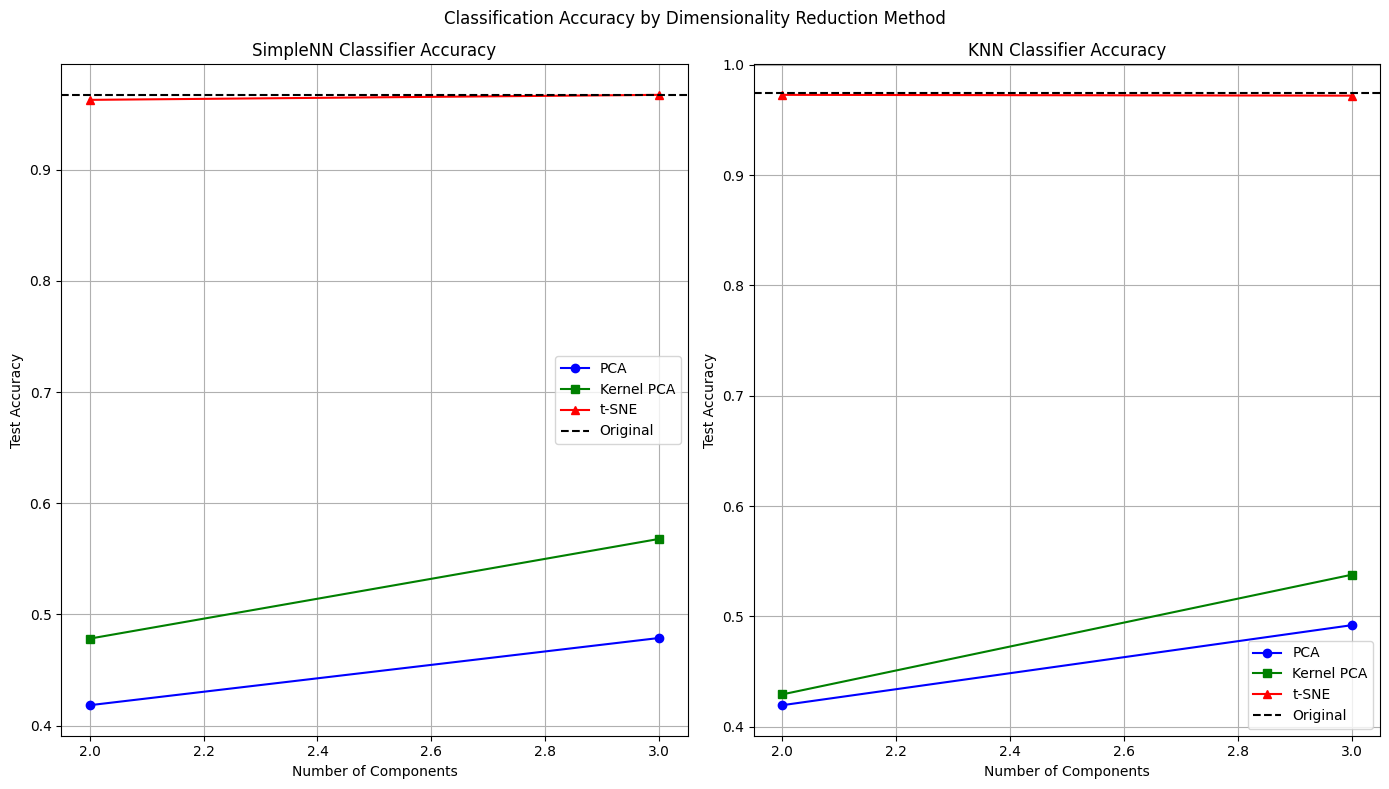

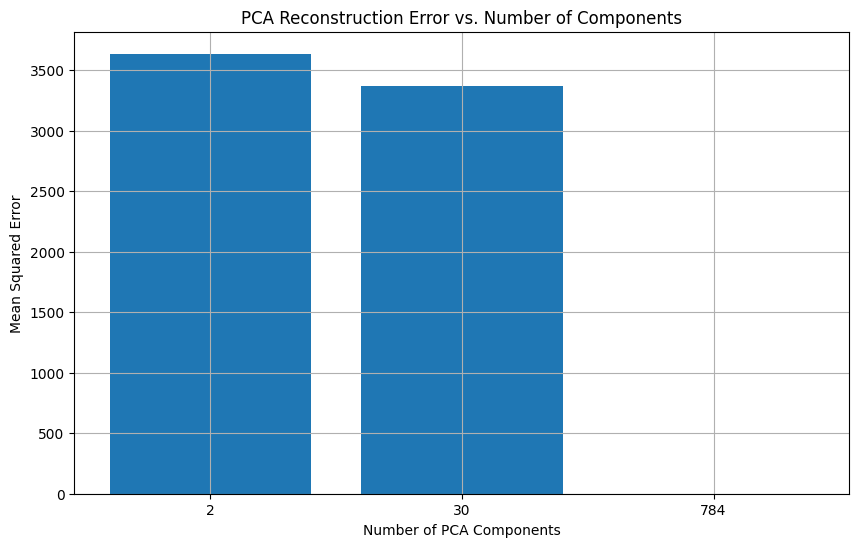

In [ ]:
import pandas as pd

print("\n\n===== Final Comparison of All Methods =====")

results_df = pd.DataFrame(all_results)
print(results_df.to_string(index=False))

results_df.to_csv(f"../result/mnist_dimensionality_reduction_comparison.csv", index=False)

plt.figure(figsize=(14, 8))

pca_results = results_df[results_df["Method"] == "PCA"]
kpca_results = results_df[results_df["Method"].str.contains("KernelPCA")]
tsne_results = results_df[results_df["Method"] == "t-SNE"]
original_results = results_df[results_df["Method"] == "Original"]

plt.subplot(1, 2, 1)
if not pca_results.empty:
    plt.plot(pca_results["n_components"], pca_results["SimpleNN_accuracy"], 
             'o-', label="PCA", color='blue')
if not kpca_results.empty:
    plt.plot(kpca_results["n_components"], kpca_results["SimpleNN_accuracy"], 
             's-', label="Kernel PCA", color='green')
if not tsne_results.empty:
    plt.plot(tsne_results["n_components"], tsne_results["SimpleNN_accuracy"], 
             '^-', label="t-SNE", color='red')
if not original_results.empty:
    plt.axhline(y=original_results["SimpleNN_accuracy"].values[0], linestyle='--', 
                label="Original", color='black')

plt.title("SimpleNN Classifier Accuracy")
plt.xlabel("Number of Components")
plt.ylabel("Test Accuracy")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
if not pca_results.empty:
    plt.plot(pca_results["n_components"], pca_results["KNN_accuracy"], 
             'o-', label="PCA", color='blue')
if not kpca_results.empty:
    plt.plot(kpca_results["n_components"], kpca_results["KNN_accuracy"], 
             's-', label="Kernel PCA", color='green')
if not tsne_results.empty:
    plt.plot(tsne_results["n_components"], tsne_results["KNN_accuracy"], 
             '^-', label="t-SNE", color='red')
if not original_results.empty:
    plt.axhline(y=original_results["KNN_accuracy"].values[0], linestyle='--', 
                label="Original", color='black')

plt.title("KNN Classifier Accuracy")
plt.xlabel("Number of Components")
plt.ylabel("Test Accuracy")
plt.grid(True)
plt.legend()

plt.suptitle("Classification Accuracy by Dimensionality Reduction Method")
plt.tight_layout()
plt.savefig(f"../result/accuracy_comparison.png")
plt.show()

plt.figure(figsize=(10, 6))
recon_errors = {
    2: pca2_mse,
    30: pca30_mse,
    784: 0
}
plt.bar(range(len(recon_errors)), list(recon_errors.values()), align='center')
plt.xticks(range(len(recon_errors)), list(recon_errors.keys()))
plt.xlabel('Number of PCA Components')
plt.ylabel('Mean Squared Error')
plt.title('PCA Reconstruction Error vs. Number of Components')
plt.grid(True)
plt.savefig(f"../result/reconstruction_error_comparison.png")
plt.show()

# Final analysis and conclusions

In [ ]:
print("\n===== Analysis and Conclusions =====")
print("1. Dimensionality Reduction Effectiveness:")
print("   - PCA with 3 components preserves about", 
      f"{results_df[results_df['Method'] == 'PCA'][results_df['n_components'] == 3]['Explained_variance'].values[0]:.1%}",
      "of the variance while reducing dimensions by 96%")
print("   - PCA with just 2 components preserves only about", 
      f"{results_df[results_df['Method'] == 'PCA'][results_df['n_components'] == 2]['Explained_variance'].values[0]:.1%}",
      "of the variance")

print("\n2. Classification Performance:")
print("   - Best SimpleNN accuracy:", 
      f"{results_df['SimpleNN_accuracy'].max():.2%}",
      f"({results_df.loc[results_df['SimpleNN_accuracy'].idxmax(), 'Method']} with",
      f"n={results_df.loc[results_df['SimpleNN_accuracy'].idxmax(), 'n_components']})")
print("   - Best KNN accuracy:", 
      f"{results_df['KNN_accuracy'].max():.2%}",
      f"({results_df.loc[results_df['KNN_accuracy'].idxmax(), 'Method']} with",
      f"n={results_df.loc[results_df['KNN_accuracy'].idxmax(), 'n_components']})")

print("\n3. Visualization Quality:")
print("   - t-SNE provides the best 2D visualization with a separation ratio of",
      f"{results_df[results_df['Method'] == 't-SNE'][results_df['n_components'] == 2]['Separation_ratio'].values[0]:.4f}")
print("   - PCA with n=2 has a separation ratio of",
      f"{results_df[results_df['Method'] == 'PCA'][results_df['n_components'] == 2]['Separation_ratio'].values[0]:.4f}")


===== Analysis and Conclusions =====
1. Dimensionality Reduction Effectiveness:
   - PCA with 3 components preserves about 23.1% of the variance while reducing dimensions by 96%
   - PCA with just 2 components preserves only about 16.9% of the variance

2. Classification Performance:
   - Best SimpleNN accuracy: 96.71% (t-SNE with n=3)
   - Best KNN accuracy: 97.44% (Original with n=784)

3. Visualization Quality:
   - t-SNE provides the best 2D visualization with a separation ratio of 4.2427
   - PCA with n=2 has a separation ratio of 1.8873


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import os
from tqdm import tqdm

os.makedirs("../result", exist_ok=True)
os.makedirs("../model", exist_ok=True)

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")

In [80]:
BATCH_SIZE = 256
EPOCHS = 100
LATENT_DIM = 32
LEARNING_RATE = 1e-3
NOISE_STD = 0.5
SEED = 42
DEVICE = device
torch.manual_seed(SEED)
np.random.seed(SEED)

In [81]:
transform = transforms.Compose([transforms.ToTensor()])
mnist_train = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
X_train = mnist_train.data.float().reshape(-1, 28*28) / 255.
X_test  = mnist_test.data.float().reshape(-1, 28*28) / 255.
y_train = mnist_train.targets
y_test  = mnist_test.targets
train_ds = TensorDataset(X_train)
test_ds  = TensorDataset(X_test)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
class AutoEncoder(nn.Module):
    def __init__(self, input_dim=784, latent_dim=32, hidden_layers=[128, 64], activation='relu', dropout_rate=0, use_batchnorm=False):
        super().__init__()

        if activation == 'relu':
            act_fn = nn.ReLU()
        elif activation == 'leaky_relu':
            act_fn = nn.LeakyReLU(0.2)
        elif activation == 'elu':
            act_fn = nn.ELU()
        elif activation == 'sigmoid':
            act_fn = nn.Sigmoid()
        elif activation == 'tanh':
            act_fn = nn.Tanh()
        else:
            raise ValueError(f"Unsupported activation function: {activation}")
        
        # Encoder
        encoder_layers = []
        last_dim = input_dim
        for h in hidden_layers:
            encoder_layers.append(nn.Linear(last_dim, h))
            if use_batchnorm:
                encoder_layers.append(nn.BatchNorm1d(h))
            encoder_layers.append(act_fn)
            if dropout_rate > 0:
                encoder_layers.append(nn.Dropout(dropout_rate))
            last_dim = h
        encoder_layers.append(nn.Linear(last_dim, latent_dim))
        self.encoder = nn.Sequential(*encoder_layers)
        
        # Decoder
        decoder_layers = []
        last_dim = latent_dim
        for h in reversed(hidden_layers):
            decoder_layers.append(nn.Linear(last_dim, h))
            if use_batchnorm:
                decoder_layers.append(nn.BatchNorm1d(h))
            decoder_layers.append(act_fn)
            if dropout_rate > 0:
                decoder_layers.append(nn.Dropout(dropout_rate))
            last_dim = h
        decoder_layers.append(nn.Linear(last_dim, input_dim))
        decoder_layers.append(nn.Sigmoid())  # 输出归一化
        self.decoder = nn.Sequential(*decoder_layers)

    def forward(self, x):
        code = self.encoder(x)
        out = self.decoder(code)
        return out, code
    
    def encode(self, x):
        return self.encoder(x)
    
    def decode(self, z):
        return self.decoder(z)

In [ ]:
class VariationalAutoEncoder(nn.Module):
    def __init__(self, input_dim=784, latent_dim=32, hidden_layers=[128, 64], activation='relu'):
        super().__init__()

        if activation == 'relu':
            act_fn = nn.ReLU()
        elif activation == 'leaky_relu':
            act_fn = nn.LeakyReLU(0.2)
        elif activation == 'elu':
            act_fn = nn.ELU()
        else:
            raise ValueError(f"Unsupported activation function: {activation}")
        
        # Encoder
        encoder_layers = []
        last_dim = input_dim
        for h in hidden_layers:
            encoder_layers.append(nn.Linear(last_dim, h))
            encoder_layers.append(act_fn)
            last_dim = h
        
        self.fc_mu = nn.Linear(last_dim, latent_dim)
        self.fc_var = nn.Linear(last_dim, latent_dim)
        self.encoder_backbone = nn.Sequential(*encoder_layers)
        
        # Decoder
        decoder_layers = []
        last_dim = latent_dim
        for h in reversed(hidden_layers):
            decoder_layers.append(nn.Linear(last_dim, h))
            decoder_layers.append(act_fn)
            last_dim = h
        decoder_layers.append(nn.Linear(last_dim, input_dim))
        decoder_layers.append(nn.Sigmoid())  # 输出归一化
        self.decoder = nn.Sequential(*decoder_layers)

    def encode(self, x):
        h = self.encoder_backbone(x)
        mu = self.fc_mu(h)
        log_var = self.fc_var(h)
        return mu, log_var
    
    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        x_recon = self.decode(z)
        return x_recon, mu, log_var

In [ ]:
def train_autoencoder(model, train_loader, test_loader, epochs, optimizer_name, 
                      loss_type, weight_decay=0, use_denoising=False, noise_std=0.5, 
                      kld_weight=0.0, save_path=None):
    model = model.to(DEVICE)
    
    # Optimizer
    if optimizer_name == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=weight_decay)
    elif optimizer_name == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9, weight_decay=weight_decay)
    elif optimizer_name == 'rmsprop':
        optimizer = optim.RMSprop(model.parameters(), lr=LEARNING_RATE, weight_decay=weight_decay)
    else:
        raise ValueError(f"未知优化器: {optimizer_name}")
    
    # Loss function
    if loss_type == 'mse':
        recon_loss_fn = nn.MSELoss(reduction='sum')
    elif loss_type == 'bce':
        recon_loss_fn = nn.BCELoss(reduction='sum')
    elif loss_type == 'huber':
        recon_loss_fn = nn.HuberLoss(reduction='sum')
    else:
        raise ValueError(f"未知loss类型: {loss_type}")
    
    # LR调度器
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)
    
    train_losses, test_losses = [], []
    best_test_loss = float('inf')
    is_vae = isinstance(model, VariationalAutoEncoder)
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        recon_loss_sum = 0
        kld_loss_sum = 0 if is_vae else None
        
        pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch [{epoch+1}/{epochs}]")
        for batch_idx, (x_batch,) in pbar:
            x_batch = x_batch.to(DEVICE)
            
            # 对输入加噪声（如果使用降噪自动编码器）
            if use_denoising:
                noise = torch.randn_like(x_batch) * noise_std
                x_input = torch.clamp(x_batch + noise, 0, 1)
            else:
                x_input = x_batch
            
            optimizer.zero_grad()
            
            # 处理VAE和普通AE不同的输出格式
            if is_vae:  # VAE模型
                output, mu, log_var = model(x_input)
                recon_loss = recon_loss_fn(output, x_batch)
                kld_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
                loss = recon_loss + kld_weight * kld_loss
                recon_loss_sum += recon_loss.item()
                kld_loss_sum += kld_loss.item()
            else:  # 普通AE模型
                output, _ = model(x_input)
                loss = recon_loss_fn(output, x_batch)
                recon_loss_sum += loss.item()
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
            if is_vae:
                pbar.set_postfix({
                    'loss': f'{loss.item()/x_batch.size(0):.4f}',
                    'recon': f'{recon_loss.item()/x_batch.size(0):.4f}',
                    'kld': f'{kld_loss.item()/x_batch.size(0):.4f}'
                })
            else:
                pbar.set_postfix({'loss': f'{loss.item()/x_batch.size(0):.4f}'})
        
        avg_train_loss = train_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)
        
        model.eval()
        test_loss = 0
        with torch.no_grad():
            for (x_batch,) in test_loader:
                x_batch = x_batch.to(DEVICE)
                
                if use_denoising:
                    noise = torch.randn_like(x_batch) * noise_std
                    x_input = torch.clamp(x_batch + noise, 0, 1)
                else:
                    x_input = x_batch
                
                if is_vae:
                    output, mu, log_var = model(x_input)
                    recon_loss = recon_loss_fn(output, x_batch)
                    kld_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
                    loss = recon_loss + kld_weight * kld_loss
                else:
                    output, _ = model(x_input)
                    loss = recon_loss_fn(output, x_batch)
                
                test_loss += loss.item()
        
        avg_test_loss = test_loss / len(test_loader.dataset)
        test_losses.append(avg_test_loss)
        
        scheduler.step(avg_test_loss)
        
        if avg_test_loss < best_test_loss and save_path:
            best_test_loss = avg_test_loss
            torch.save(model.state_dict(), save_path)
            print(f"Model saved to {save_path} with test loss: {best_test_loss:.5f}")
        
        if is_vae:
            print(f"Epoch {epoch+1}/{epochs}: "
                  f"Train Loss={avg_train_loss:.5f} "
                  f"(Recon: {recon_loss_sum/len(train_loader.dataset):.5f}, "
                  f"KLD: {kld_loss_sum/len(train_loader.dataset):.5f}) | "
                  f"Test Loss={avg_test_loss:.5f}")
        else:
            print(f"Epoch {epoch+1}/{epochs}: "
                  f"Train Loss={avg_train_loss:.5f} | "
                  f"Test Loss={avg_test_loss:.5f}")
    
    return train_losses, test_losses

In [ ]:
def plot_loss_curves(history_dict, title, save_path=None):
    plt.figure(figsize=(10,6))
    for label, his in history_dict.items():
        plt.plot(his["train"], label=f'Train-{label}')
        plt.plot(his["test"], linestyle='--', label=f'Test-{label}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
        print(f"Loss curves saved to {save_path}")
    plt.show()

def show_reconstructions(model, X, title='', save_path=None, is_vae=False):
    model.eval()
    with torch.no_grad():
        x = X[:10].to(DEVICE)
        if is_vae:
            recon, _, _ = model(x)
            recon = recon.cpu().numpy()
        else:
            recon, _ = model(x)
            recon = recon.cpu().numpy()
        orig = x.cpu().numpy()
    
    plt.figure(figsize=(20, 4))
    for i in range(10):
        plt.subplot(2, 10, i+1)
        plt.imshow(orig[i].reshape(28, 28), cmap='gray')
        plt.axis('off')
        if i == 0:
            plt.ylabel("Original", fontsize=14)
        
        plt.subplot(2, 10, i+11)
        plt.imshow(recon[i].reshape(28, 28), cmap='gray')
        plt.axis('off')
        if i == 0:
            plt.ylabel("Reconstructed", fontsize=14)
    
    plt.suptitle(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
        print(f"Reconstruction image saved to {save_path}")
    plt.show()

def plot_latent_space(model, X, y, title='', save_path=None, is_vae=False):
    """将数据映射到2D潜在空间并可视化"""
    model.eval()
    with torch.no_grad():
        x = X.to(DEVICE)
        if is_vae:
            mu, _ = model.encode(x)
            z = mu.cpu().numpy()
        else:
            z = model.encode(x).cpu().numpy()
    
    if z.shape[1] > 2:
        from sklearn.manifold import TSNE
        z = TSNE(n_components=2).fit_transform(z)
    
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(z[:, 0], z[:, 1], c=y.numpy(), cmap='tab10')
    plt.colorbar(scatter)
    plt.title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
        print(f"Latent space visualization saved to {save_path}")
    plt.show()

def compare_mse(recon_mse, title='Autoencoder Reconstruction MSE Comparison', save_path=None):
    plt.figure(figsize=(12, 6))
    bars = plt.bar(range(len(recon_mse)), list(recon_mse.values()), tick_label=list(recon_mse.keys()))
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                 f'{height:.4f}', ha='center', va='bottom', rotation=0)
    
    plt.ylabel('MSE on Test Set')
    plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
        print(f"MSE comparison chart saved to {save_path}")
    plt.show()


### 基础模型 MSE

Using device: mps

==================== 训练 Baseline_MSE ====================


Epoch [1/100]: 100%|██████████| 235/235 [00:01<00:00, 219.23it/s, loss=42.9547]


Model saved to ../model/Baseline_MSE_model.pth with test loss: 43.43762
Epoch 1/100: Train Loss=59.53045 | Test Loss=43.43762


Epoch [2/100]: 100%|██████████| 235/235 [00:01<00:00, 206.83it/s, loss=25.8867]


Model saved to ../model/Baseline_MSE_model.pth with test loss: 26.06402
Epoch 2/100: Train Loss=32.39365 | Test Loss=26.06402


...

Epoch 98/100: Train Loss=4.92820 | Test Loss=5.09347


Epoch [99/100]: 100%|██████████| 235/235 [00:01<00:00, 183.37it/s, loss=5.1515]


Model saved to ../model/Baseline_MSE_model.pth with test loss: 5.01160
Epoch 99/100: Train Loss=4.92149 | Test Loss=5.01160


Epoch [100/100]: 100%|██████████| 235/235 [00:01<00:00, 193.79it/s, loss=5.1790]


Model saved to ../model/Baseline_MSE_model.pth with test loss: 5.00769
Epoch 100/100: Train Loss=4.90147 | Test Loss=5.00769
Baseline_MSE 重建MSE: 0.006387
Reconstruction image saved to ../result/Baseline_MSE_reconstruction.png


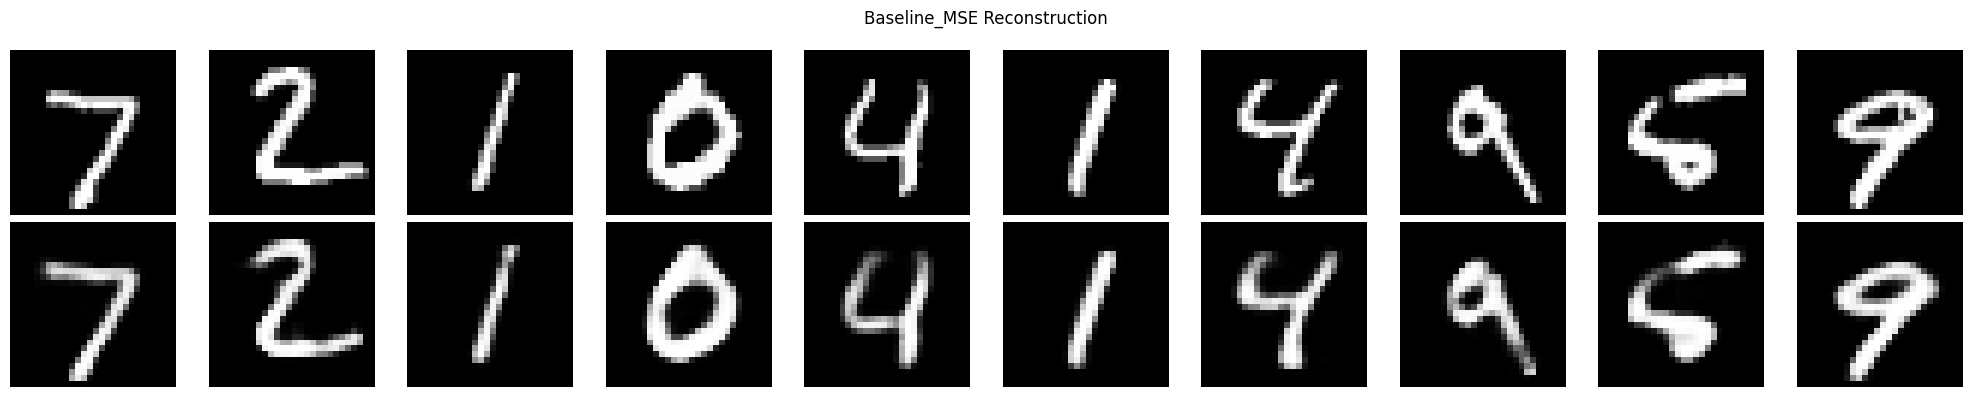

Latent space visualization saved to ../result/Baseline_MSE_latent_space.png


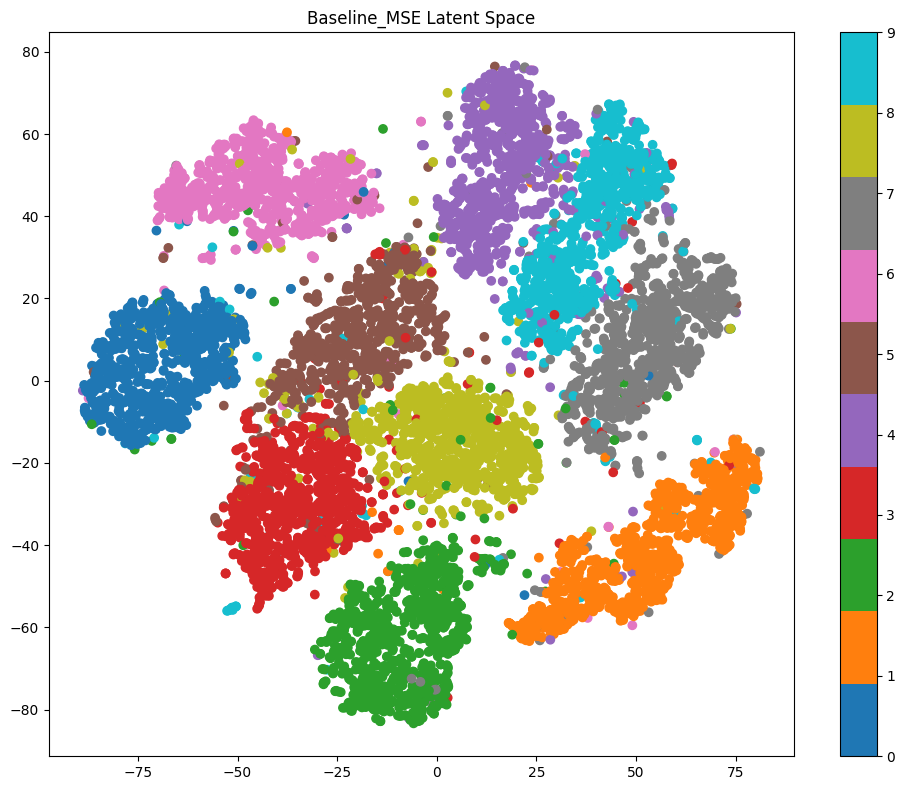

In [95]:
print(f"Using device: {DEVICE}")
history_dict = {}
recon_mse = {}
best_model = None
best_mse = float('inf')

print("\n" + "="*20 + " 训练 Baseline_MSE " + "="*20)
model_name = "Baseline_MSE"
model = AutoEncoder(
    input_dim=784, 
    latent_dim=LATENT_DIM,
    hidden_layers=[128, 64],
    activation='relu',
    dropout_rate=0,
    use_batchnorm=False
)
model_save_path = f"../model/{model_name}_model.pth"

train_losses, test_losses = train_autoencoder(
    model, 
    train_loader, 
    test_loader,
    epochs=EPOCHS,
    optimizer_name='adam',
    loss_type='mse',
    weight_decay=0,
    use_denoising=False,
    save_path=model_save_path
)
history_dict[model_name] = {"train": train_losses, "test": test_losses}

model.load_state_dict(torch.load(model_save_path))
model.eval()
with torch.no_grad():
    recon, _ = model(X_test.to(DEVICE))
    pred = recon.cpu().numpy()
    mse = np.mean((X_test.numpy() - pred) ** 2)
    recon_mse[model_name] = mse
    print(f"{model_name} 重建MSE: {mse:.6f}")
    
    if mse < best_mse:
        best_mse = mse
        best_model = model_name
        torch.save(model.state_dict(), "../model/best_model.pth")

show_reconstructions(
    model, 
    X_test, 
    title=f"{model_name} Reconstruction",
    save_path=f"../result/{model_name}_reconstruction.png",
    is_vae=False
)

plot_latent_space(
    model, 
    X_test, 
    y_test,
    title=f"{model_name} Latent Space",
    save_path=f"../result/{model_name}_latent_space.png",
    is_vae=False
)

### 基础模型 BCE


==================== 训练 Baseline_BCE ====================


Epoch [1/100]: 100%|██████████| 235/235 [00:01<00:00, 204.66it/s, loss=184.1240]


Model saved to ../model/Baseline_BCE_model.pth with test loss: 178.47699
Epoch 1/100: Train Loss=223.39939 | Test Loss=178.47699


Epoch [2/100]: 100%|██████████| 235/235 [00:01<00:00, 228.33it/s, loss=122.5120]


Model saved to ../model/Baseline_BCE_model.pth with test loss: 127.19529
Epoch 2/100: Train Loss=147.01407 | Test Loss=127.19529


...

Model saved to ../model/Baseline_BCE_model.pth with test loss: 63.33121
Epoch 98/100: Train Loss=63.53166 | Test Loss=63.33121


Epoch [99/100]: 100%|██████████| 235/235 [00:01<00:00, 205.13it/s, loss=59.3590]


Epoch 99/100: Train Loss=63.48430 | Test Loss=63.59400


Epoch [100/100]: 100%|██████████| 235/235 [00:01<00:00, 205.82it/s, loss=64.8594]


Epoch 100/100: Train Loss=63.43290 | Test Loss=63.55802
Baseline_BCE 重建MSE: 0.006427
Reconstruction image saved to ../result/Baseline_BCE_reconstruction.png


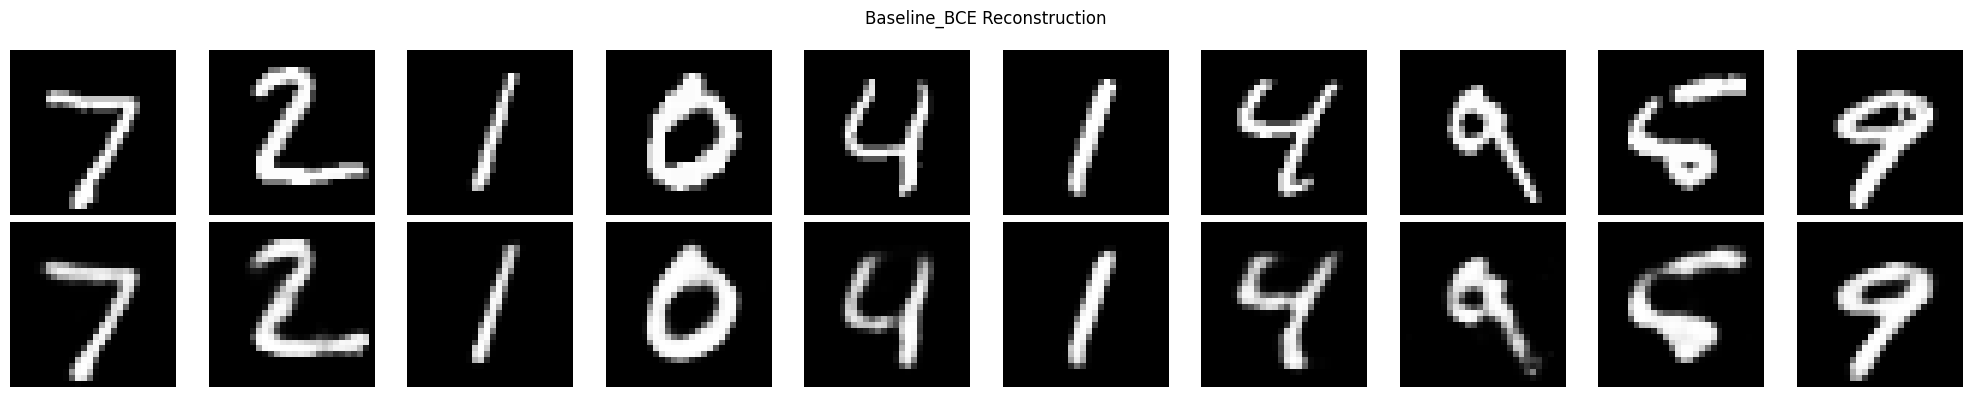

Latent space visualization saved to ../result/Baseline_BCE_latent_space.png


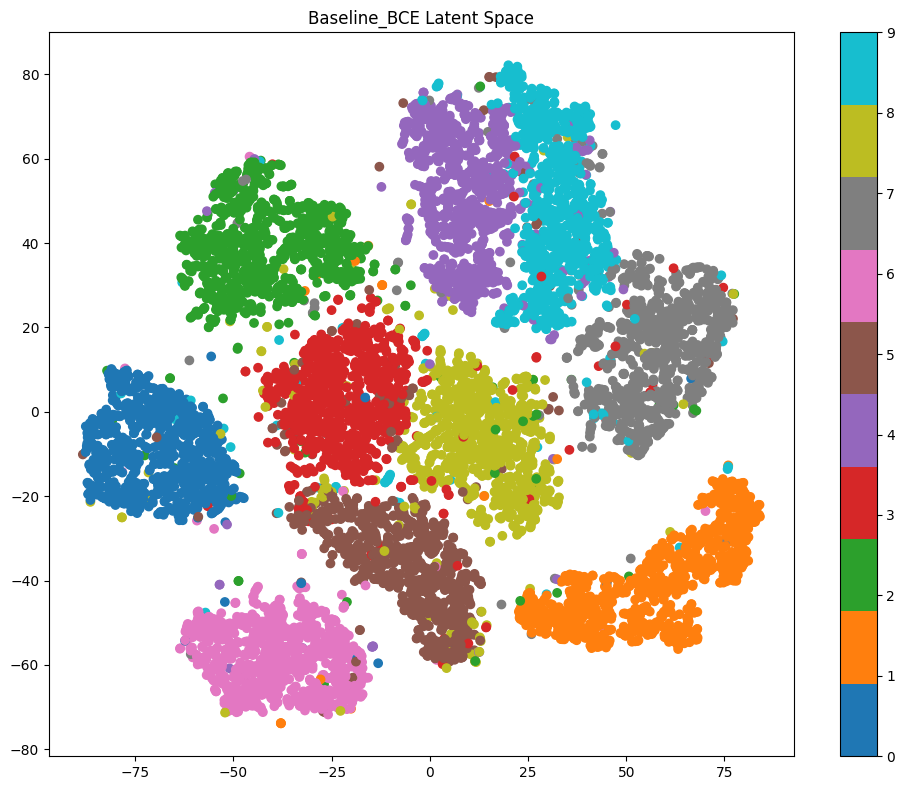

In [96]:
print("\n" + "="*20 + " 训练 Baseline_BCE " + "="*20)
model_name = "Baseline_BCE"
model = AutoEncoder(
    input_dim=784, 
    latent_dim=LATENT_DIM,
    hidden_layers=[128, 64],
    activation='relu',
    dropout_rate=0,
    use_batchnorm=False
)
model_save_path = f"../model/{model_name}_model.pth"

train_losses, test_losses = train_autoencoder(
    model, 
    train_loader, 
    test_loader,
    epochs=EPOCHS,
    optimizer_name='adam',
    loss_type='bce',
    weight_decay=0,
    use_denoising=False,
    save_path=model_save_path
)
history_dict[model_name] = {"train": train_losses, "test": test_losses}

model.load_state_dict(torch.load(model_save_path))
model.eval()
with torch.no_grad():
    recon, _ = model(X_test.to(DEVICE))
    pred = recon.cpu().numpy()
    mse = np.mean((X_test.numpy() - pred) ** 2)
    recon_mse[model_name] = mse
    print(f"{model_name} 重建MSE: {mse:.6f}")
    
    if mse < best_mse:
        best_mse = mse
        best_model = model_name
        torch.save(model.state_dict(), "../model/best_model.pth")

show_reconstructions(
    model, 
    X_test, 
    title=f"{model_name} Reconstruction",
    save_path=f"../result/{model_name}_reconstruction.png",
    is_vae=False
)

plot_latent_space(
    model, 
    X_test, 
    y_test,
    title=f"{model_name} Latent Space",
    save_path=f"../result/{model_name}_latent_space.png",
    is_vae=False
)

### 深层自编码器


==================== 训练 Deep_AE ====================


Epoch [1/100]: 100%|██████████| 235/235 [00:01<00:00, 132.07it/s, loss=40.8289]


Model saved to ../model/Deep_AE_model.pth with test loss: 43.00180
Epoch 1/100: Train Loss=56.55985 | Test Loss=43.00180


Epoch [2/100]: 100%|██████████| 235/235 [00:01<00:00, 153.53it/s, loss=32.4738]


Model saved to ../model/Deep_AE_model.pth with test loss: 31.87816
Epoch 2/100: Train Loss=37.42078 | Test Loss=31.87816


...

Epoch 98/100: Train Loss=5.31609 | Test Loss=5.69002


Epoch [99/100]: 100%|██████████| 235/235 [00:01<00:00, 160.80it/s, loss=5.5635]


Epoch 99/100: Train Loss=5.27210 | Test Loss=5.79728


Epoch [100/100]: 100%|██████████| 235/235 [00:01<00:00, 155.61it/s, loss=5.0252]


Model saved to ../model/Deep_AE_model.pth with test loss: 5.61514
Epoch 100/100: Train Loss=5.25371 | Test Loss=5.61514
Deep_AE 重建MSE: 0.007162
Reconstruction image saved to ../result/Deep_AE_reconstruction.png


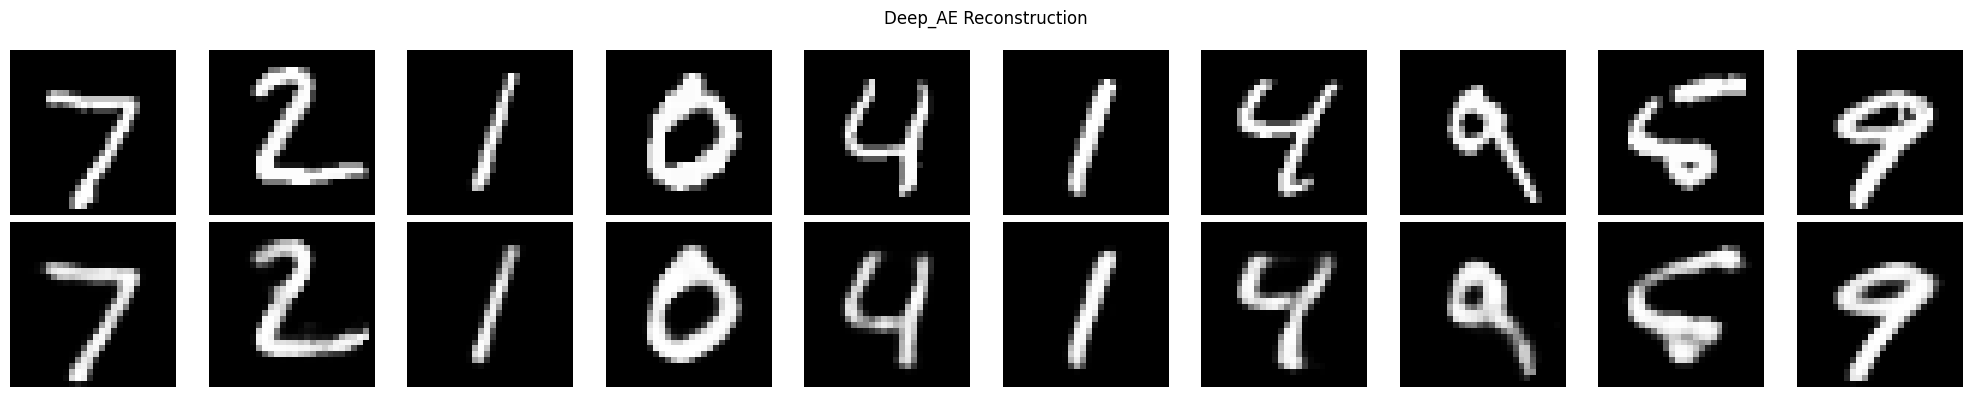

Latent space visualization saved to ../result/Deep_AE_latent_space.png


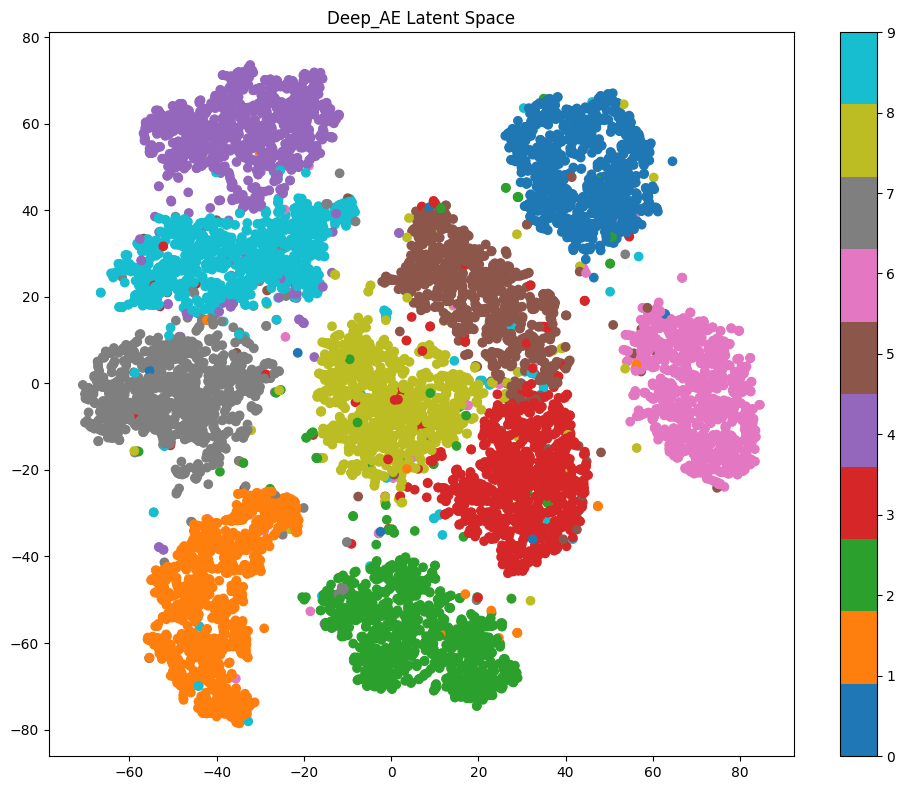

In [97]:
print("\n" + "="*20 + " 训练 Deep_AE " + "="*20)
model_name = "Deep_AE"
model = AutoEncoder(
    input_dim=784, 
    latent_dim=LATENT_DIM,
    hidden_layers=[256, 128, 64],
    activation='relu',
    dropout_rate=0,
    use_batchnorm=False
)
model_save_path = f"../model/{model_name}_model.pth"

train_losses, test_losses = train_autoencoder(
    model, 
    train_loader, 
    test_loader,
    epochs=EPOCHS,
    optimizer_name='adam',
    loss_type='mse',
    weight_decay=1e-5,
    use_denoising=False,
    save_path=model_save_path
)
history_dict[model_name] = {"train": train_losses, "test": test_losses}

model.load_state_dict(torch.load(model_save_path))
model.eval()
with torch.no_grad():
    recon, _ = model(X_test.to(DEVICE))
    pred = recon.cpu().numpy()
    mse = np.mean((X_test.numpy() - pred) ** 2)
    recon_mse[model_name] = mse
    print(f"{model_name} 重建MSE: {mse:.6f}")
    
    if mse < best_mse:
        best_mse = mse
        best_model = model_name
        torch.save(model.state_dict(), "../model/best_model.pth")

show_reconstructions(
    model, 
    X_test, 
    title=f"{model_name} Reconstruction",
    save_path=f"../result/{model_name}_reconstruction.png",
    is_vae=False
)

plot_latent_space(
    model, 
    X_test, 
    y_test,
    title=f"{model_name} Latent Space",
    save_path=f"../result/{model_name}_latent_space.png",
    is_vae=False
)

### 降噪自编码器


==================== 训练 Denoising_AE ====================


Epoch [1/100]: 100%|██████████| 235/235 [00:01<00:00, 187.89it/s, loss=46.5740]


Model saved to ../model/Denoising_AE_model.pth with test loss: 45.88062
Epoch 1/100: Train Loss=59.47322 | Test Loss=45.88062


Epoch [2/100]: 100%|██████████| 235/235 [00:01<00:00, 177.33it/s, loss=29.3318]


Model saved to ../model/Denoising_AE_model.pth with test loss: 28.70262
Epoch 2/100: Train Loss=36.90437 | Test Loss=28.70262


...

Epoch 98/100: Train Loss=6.69840 | Test Loss=6.74317


Epoch [99/100]: 100%|██████████| 235/235 [00:01<00:00, 218.76it/s, loss=6.5783]


Model saved to ../model/Denoising_AE_model.pth with test loss: 6.59131
Epoch 99/100: Train Loss=6.67437 | Test Loss=6.59131


Epoch [100/100]: 100%|██████████| 235/235 [00:01<00:00, 222.07it/s, loss=6.6907]


Epoch 100/100: Train Loss=6.66584 | Test Loss=6.74305
Denoising_AE 重建MSE: 0.009460
Reconstruction image saved to ../result/Denoising_AE_reconstruction.png


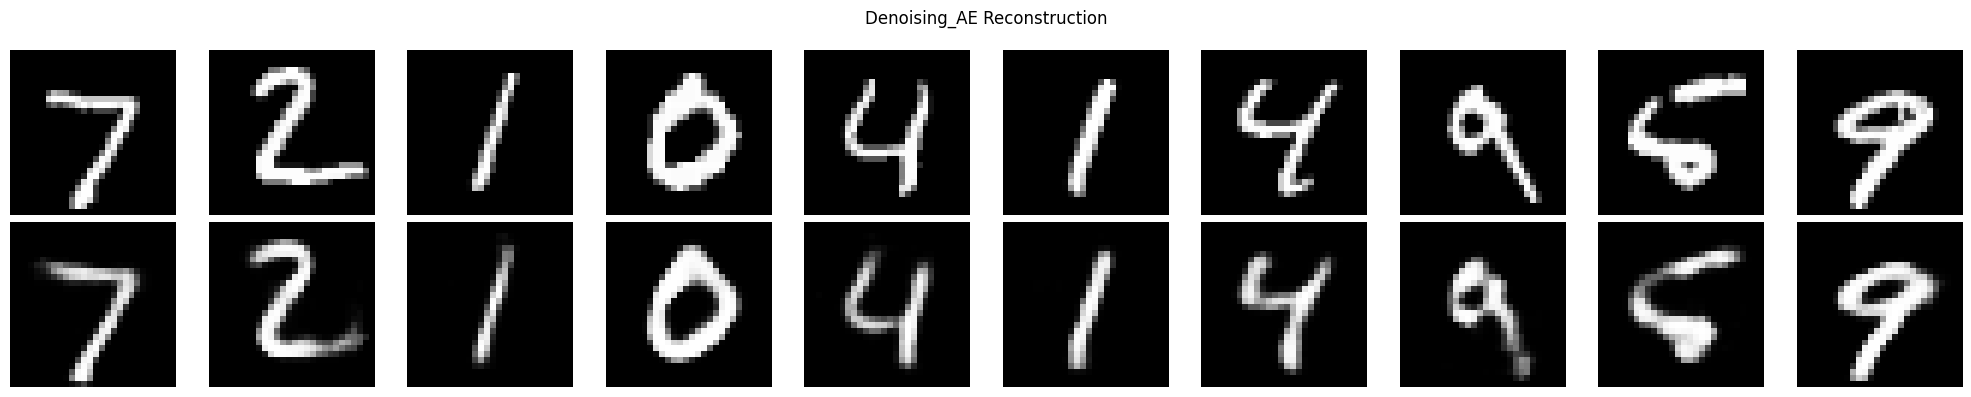

Latent space visualization saved to ../result/Denoising_AE_latent_space.png


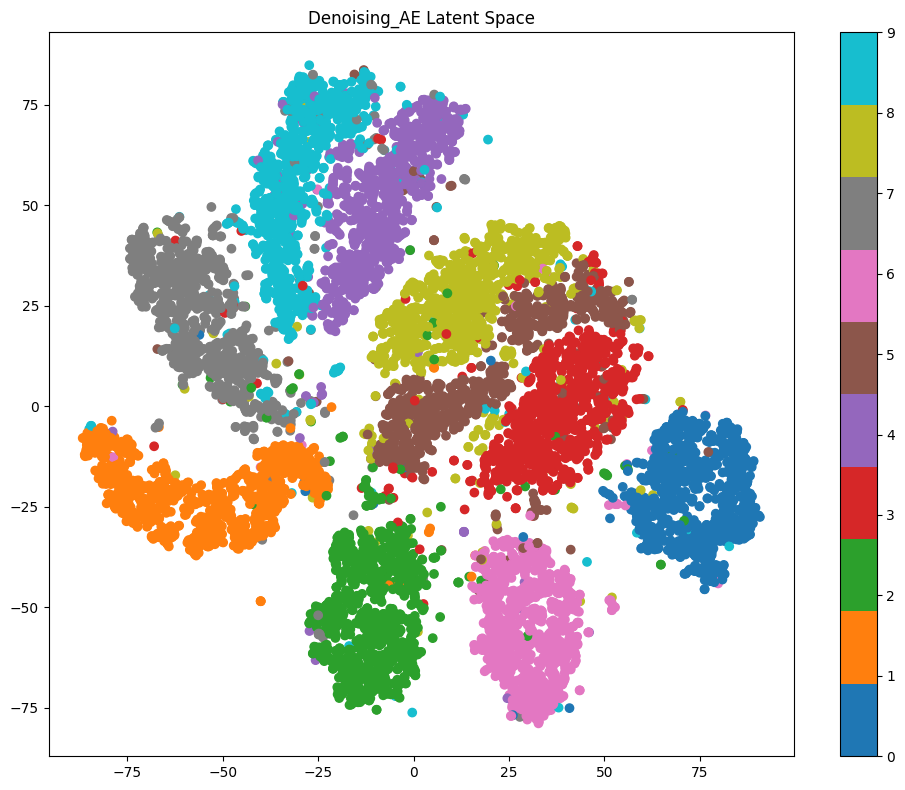

In [98]:
print("\n" + "="*20 + " 训练 Denoising_AE " + "="*20)
model_name = "Denoising_AE"
model = AutoEncoder(
    input_dim=784, 
    latent_dim=LATENT_DIM,
    hidden_layers=[128, 64],
    activation='relu',
    dropout_rate=0,
    use_batchnorm=False
)
model_save_path = f"../model/{model_name}_model.pth"

train_losses, test_losses = train_autoencoder(
    model, 
    train_loader, 
    test_loader,
    epochs=EPOCHS,
    optimizer_name='adam',
    loss_type='mse',
    weight_decay=0,
    use_denoising=True,
    noise_std=0.2,
    save_path=model_save_path
)
history_dict[model_name] = {"train": train_losses, "test": test_losses}

model.load_state_dict(torch.load(model_save_path))
model.eval()
with torch.no_grad():
    recon, _ = model(X_test.to(DEVICE))
    pred = recon.cpu().numpy()
    mse = np.mean((X_test.numpy() - pred) ** 2)
    recon_mse[model_name] = mse
    print(f"{model_name} 重建MSE: {mse:.6f}")
    
    if mse < best_mse:
        best_mse = mse
        best_model = model_name
        torch.save(model.state_dict(), "../model/best_model.pth")

show_reconstructions(
    model, 
    X_test, 
    title=f"{model_name} Reconstruction",
    save_path=f"../result/{model_name}_reconstruction.png",
    is_vae=False
)

plot_latent_space(
    model, 
    X_test, 
    y_test,
    title=f"{model_name} Latent Space",
    save_path=f"../result/{model_name}_latent_space.png",
    is_vae=False
)

### 正则化自编码器


==================== 训练 Regularized_AE ====================


Epoch [1/100]: 100%|██████████| 235/235 [00:02<00:00, 94.20it/s, loss=30.3679] 


Model saved to ../model/Regularized_AE_model.pth with test loss: 26.89156
Epoch 1/100: Train Loss=48.99991 | Test Loss=26.89156


Epoch [2/100]: 100%|██████████| 235/235 [00:01<00:00, 122.32it/s, loss=28.5470]


Model saved to ../model/Regularized_AE_model.pth with test loss: 22.46193
Epoch 2/100: Train Loss=29.37645 | Test Loss=22.46193


...

Model saved to ../model/Regularized_AE_model.pth with test loss: 13.37042
Epoch 98/100: Train Loss=21.14372 | Test Loss=13.37042


Epoch [99/100]: 100%|██████████| 235/235 [00:01<00:00, 130.24it/s, loss=22.9718]


Epoch 99/100: Train Loss=21.12932 | Test Loss=13.38701


Epoch [100/100]: 100%|██████████| 235/235 [00:01<00:00, 128.93it/s, loss=22.7067]


Epoch 100/100: Train Loss=21.14317 | Test Loss=13.40009
Regularized_AE 重建MSE: 0.017054
Reconstruction image saved to ../result/Regularized_AE_reconstruction.png


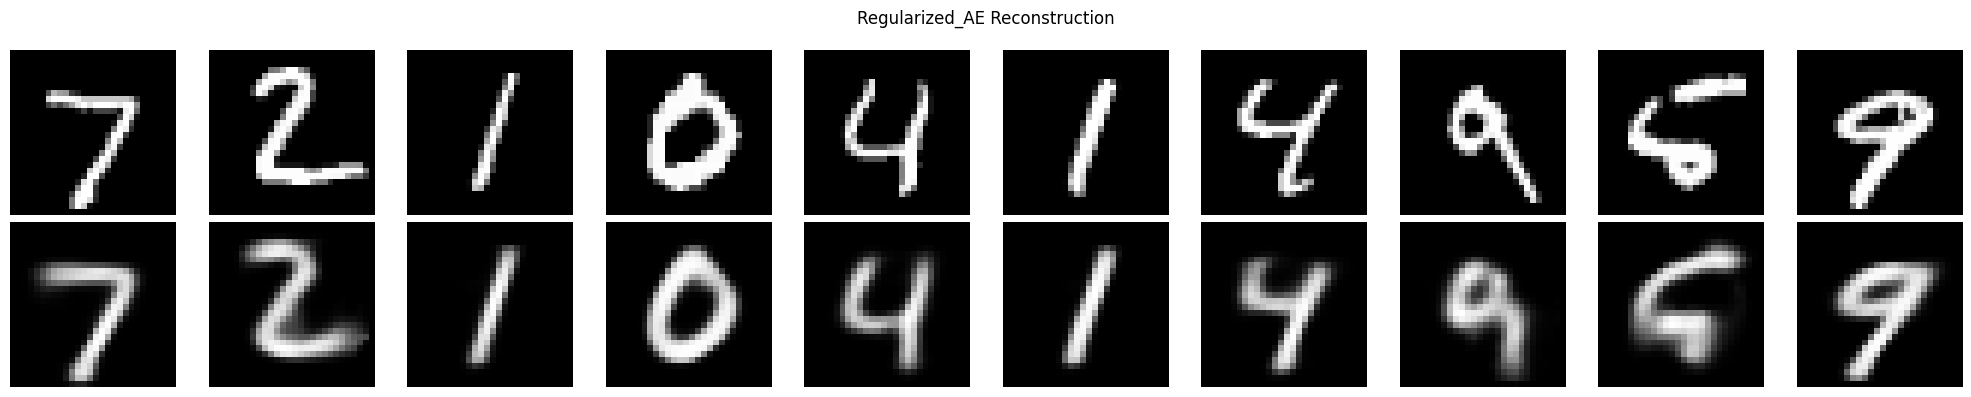

Latent space visualization saved to ../result/Regularized_AE_latent_space.png


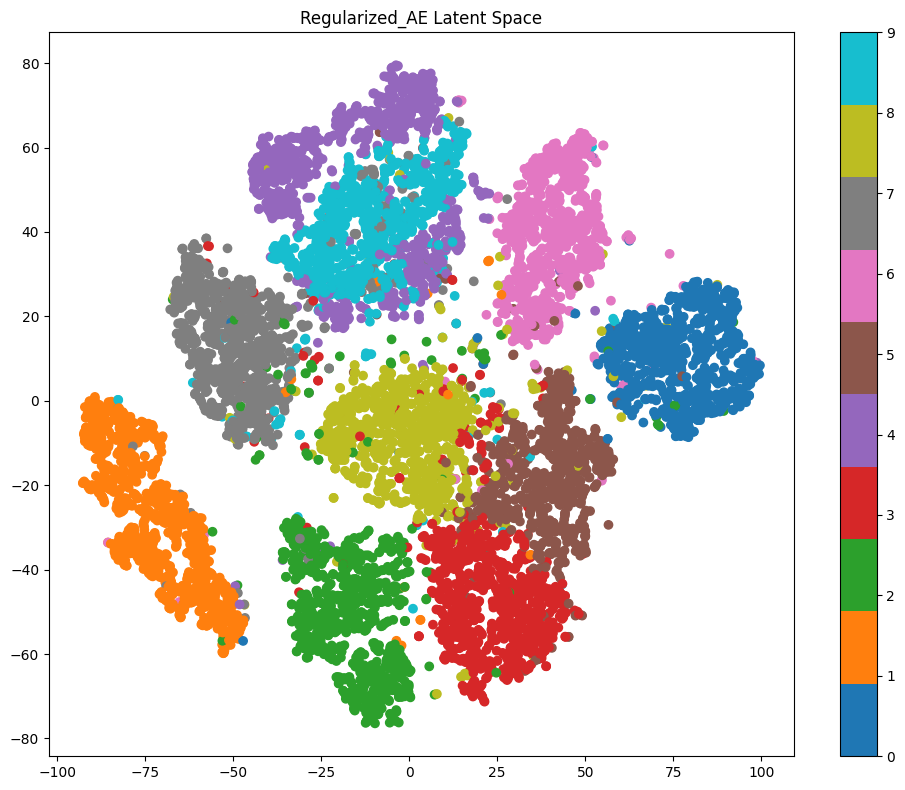

In [99]:
print("\n" + "="*20 + " 训练 Regularized_AE " + "="*20)
model_name = "Regularized_AE"
model = AutoEncoder(
    input_dim=784, 
    latent_dim=LATENT_DIM,
    hidden_layers=[128, 64],
    activation='relu',
    dropout_rate=0.2,
    use_batchnorm=True
)
model_save_path = f"../model/{model_name}_model.pth"

train_losses, test_losses = train_autoencoder(
    model, 
    train_loader, 
    test_loader,
    epochs=EPOCHS,
    optimizer_name='adam',
    loss_type='mse',
    weight_decay=1e-4,
    use_denoising=False,
    save_path=model_save_path
)
history_dict[model_name] = {"train": train_losses, "test": test_losses}

model.load_state_dict(torch.load(model_save_path))
model.eval()
with torch.no_grad():
    recon, _ = model(X_test.to(DEVICE))
    pred = recon.cpu().numpy()
    mse = np.mean((X_test.numpy() - pred) ** 2)
    recon_mse[model_name] = mse
    print(f"{model_name} 重建MSE: {mse:.6f}")
    
    if mse < best_mse:
        best_mse = mse
        best_model = model_name
        torch.save(model.state_dict(), "../model/best_model.pth")

show_reconstructions(
    model, 
    X_test, 
    title=f"{model_name} Reconstruction",
    save_path=f"../result/{model_name}_reconstruction.png",
    is_vae=False
)

plot_latent_space(
    model, 
    X_test, 
    y_test,
    title=f"{model_name} Latent Space",
    save_path=f"../result/{model_name}_latent_space.png",
    is_vae=False
)

### VAE


==================== 训练 VAE ====================


Epoch [1/100]: 100%|██████████| 235/235 [00:01<00:00, 146.40it/s, loss=39.5176, recon=39.3855, kld=132.1264]


Model saved to ../model/VAE_model.pth with test loss: 39.09996
Epoch 1/100: Train Loss=56.13358 (Recon: 56.02317, KLD: 110.40995) | Test Loss=39.09996


Epoch [2/100]: 100%|██████████| 235/235 [00:01<00:00, 179.76it/s, loss=25.4425, recon=25.2013, kld=241.2307]


Model saved to ../model/VAE_model.pth with test loss: 26.68795
Epoch 2/100: Train Loss=31.67194 (Recon: 31.46571, KLD: 206.22132) | Test Loss=26.68795


...

Model saved to ../model/VAE_model.pth with test loss: 4.76952
Epoch 98/100: Train Loss=4.66016 (Recon: 4.50534, KLD: 154.81993) | Test Loss=4.76952


Epoch [99/100]: 100%|██████████| 235/235 [00:01<00:00, 166.12it/s, loss=5.2158, recon=5.0628, kld=152.9443]


Model saved to ../model/VAE_model.pth with test loss: 4.73736
Epoch 99/100: Train Loss=4.64474 (Recon: 4.48964, KLD: 155.10746) | Test Loss=4.73736


Epoch [100/100]: 100%|██████████| 235/235 [00:01<00:00, 163.11it/s, loss=4.3198, recon=4.1680, kld=151.8673]


Epoch 100/100: Train Loss=4.62607 (Recon: 4.47128, KLD: 154.78639) | Test Loss=4.76166
VAE 重建MSE: 0.005844
Reconstruction image saved to ../result/VAE_reconstruction.png


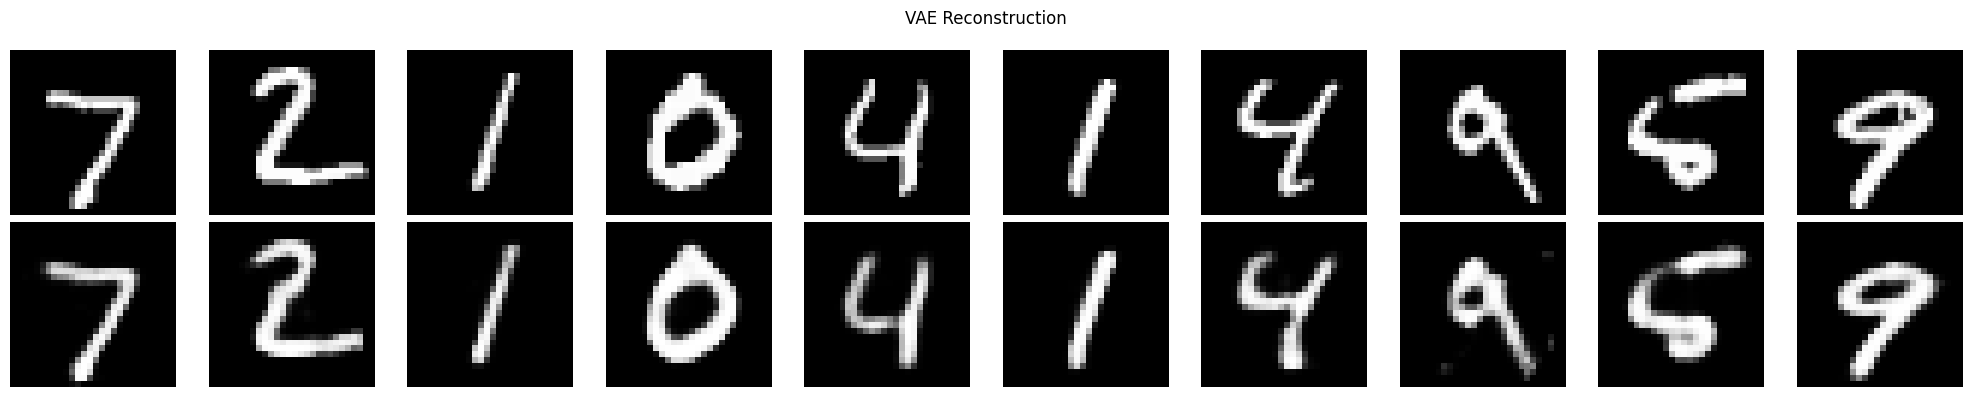

Latent space visualization saved to ../result/VAE_latent_space.png


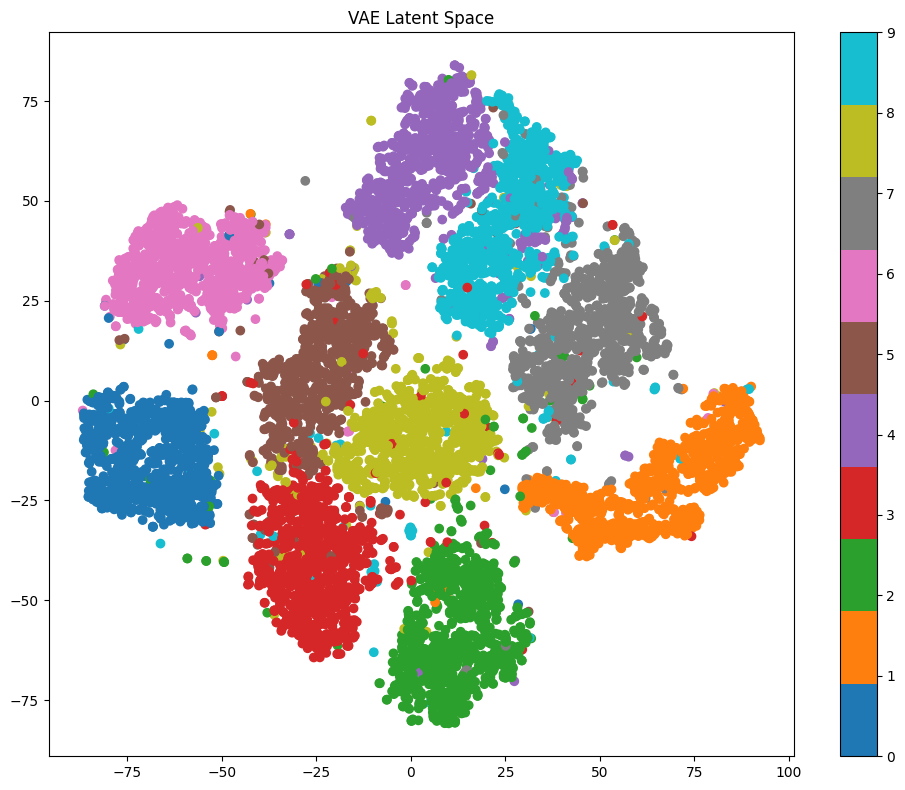

In [100]:
print("\n" + "="*20 + " 训练 VAE " + "="*20)
model_name = "VAE"
model = VariationalAutoEncoder(
    input_dim=784,
    latent_dim=LATENT_DIM,
    hidden_layers=[128, 64],
    activation='relu'
)
model_save_path = f"../model/{model_name}_model.pth"

train_losses, test_losses = train_autoencoder(
    model, 
    train_loader, 
    test_loader,
    epochs=EPOCHS,
    optimizer_name='adam',
    loss_type='mse',
    weight_decay=0,
    use_denoising=False,
    kld_weight=0.001,
    save_path=model_save_path
)
history_dict[model_name] = {"train": train_losses, "test": test_losses}

model.load_state_dict(torch.load(model_save_path))
model.eval()
with torch.no_grad():
    recon, _, _ = model(X_test.to(DEVICE))
    pred = recon.cpu().numpy()
    mse = np.mean((X_test.numpy() - pred) ** 2)
    recon_mse[model_name] = mse
    print(f"{model_name} 重建MSE: {mse:.6f}")
    
    if mse < best_mse:
        best_mse = mse
        best_model = model_name
        torch.save(model.state_dict(), "../model/best_model.pth")

show_reconstructions(
    model, 
    X_test, 
    title=f"{model_name} Reconstruction",
    save_path=f"../result/{model_name}_reconstruction.png",
    is_vae=True
)

plot_latent_space(
    model, 
    X_test, 
    y_test,
    title=f"{model_name} Latent Space",
    save_path=f"../result/{model_name}_latent_space.png",
    is_vae=True
)

### LeakyReLU 自编码器


==================== 训练 LeakyReLU_AE ====================


Epoch [1/100]: 100%|██████████| 235/235 [00:01<00:00, 125.60it/s, loss=25.0748]


Model saved to ../model/LeakyReLU_AE_model.pth with test loss: 21.52636
Epoch 1/100: Train Loss=44.20258 | Test Loss=21.52636


Epoch [2/100]: 100%|██████████| 235/235 [00:01<00:00, 130.78it/s, loss=19.7257]


Model saved to ../model/LeakyReLU_AE_model.pth with test loss: 16.61832
Epoch 2/100: Train Loss=22.14806 | Test Loss=16.61832


...

Epoch 98/100: Train Loss=11.44792 | Test Loss=6.21625


Epoch [99/100]: 100%|██████████| 235/235 [00:01<00:00, 145.83it/s, loss=11.5427]


Model saved to ../model/LeakyReLU_AE_model.pth with test loss: 6.20747
Epoch 99/100: Train Loss=11.47756 | Test Loss=6.20747


Epoch [100/100]: 100%|██████████| 235/235 [00:01<00:00, 129.87it/s, loss=11.6291]


Model saved to ../model/LeakyReLU_AE_model.pth with test loss: 6.19894
Epoch 100/100: Train Loss=11.44544 | Test Loss=6.19894
LeakyReLU_AE 重建MSE: 0.007907
Reconstruction image saved to ../result/LeakyReLU_AE_reconstruction.png


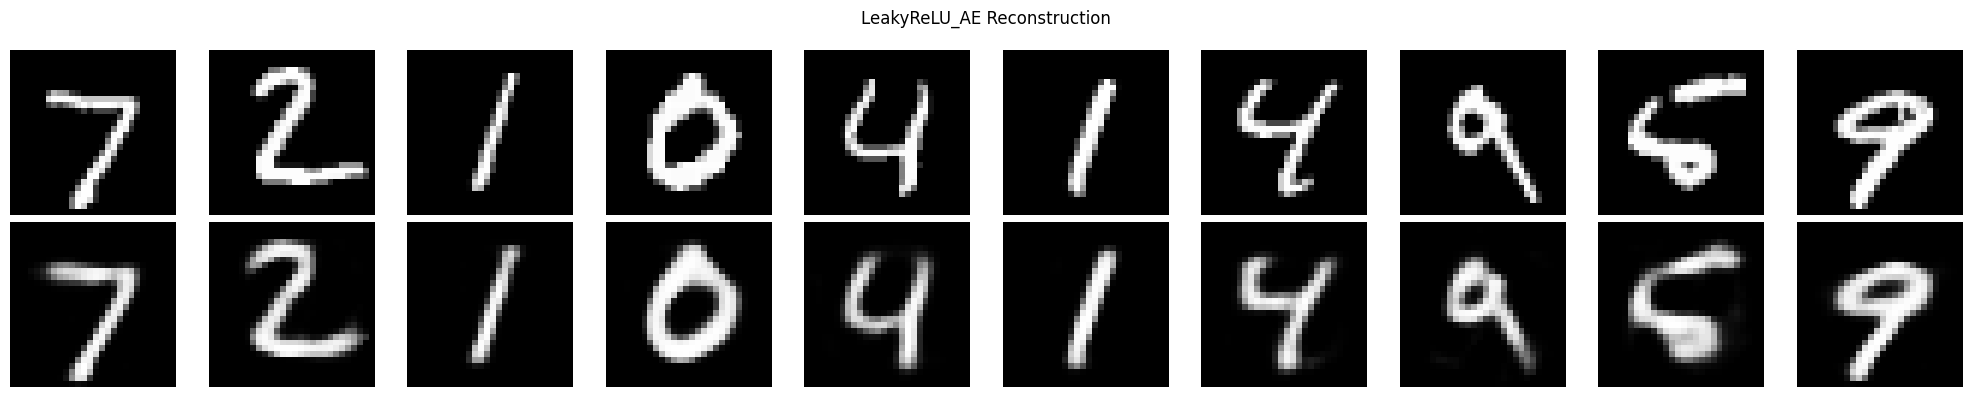

Latent space visualization saved to ../result/LeakyReLU_AE_latent_space.png


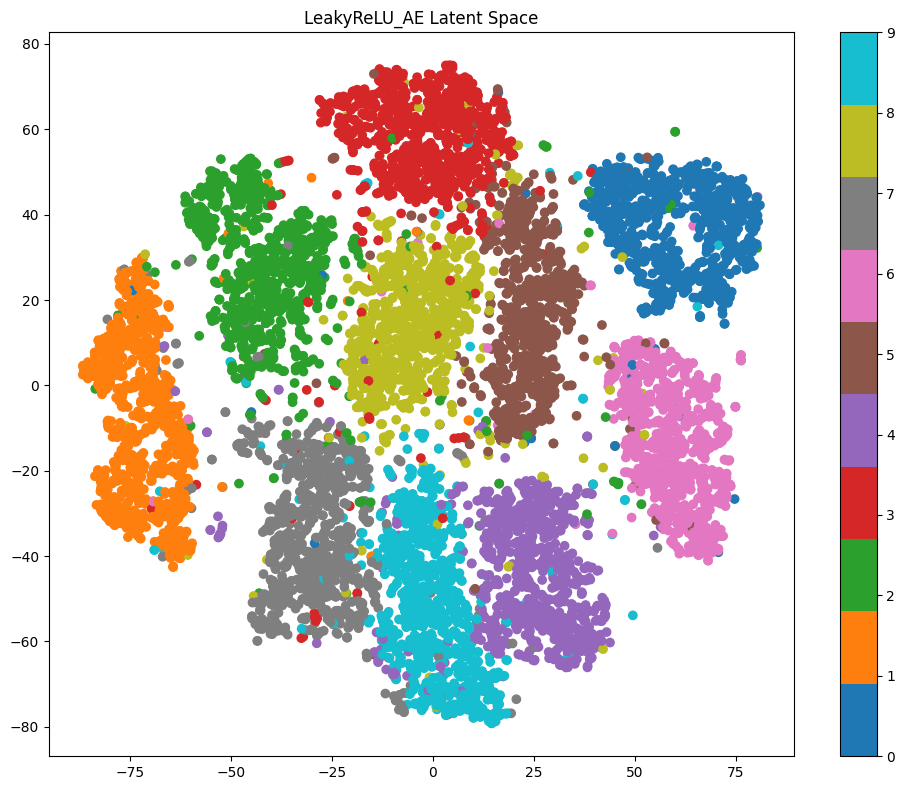

In [101]:
print("\n" + "="*20 + " 训练 LeakyReLU_AE " + "="*20)
model_name = "LeakyReLU_AE"
model = AutoEncoder(
    input_dim=784, 
    latent_dim=LATENT_DIM,
    hidden_layers=[128, 64],
    activation='leaky_relu',
    dropout_rate=0.1,
    use_batchnorm=True
)
model_save_path = f"../model/{model_name}_model.pth"

train_losses, test_losses = train_autoencoder(
    model, 
    train_loader, 
    test_loader,
    epochs=EPOCHS,
    optimizer_name='adam',
    loss_type='mse',
    weight_decay=1e-5,
    use_denoising=False,
    save_path=model_save_path
)
history_dict[model_name] = {"train": train_losses, "test": test_losses}

model.load_state_dict(torch.load(model_save_path))
model.eval()
with torch.no_grad():
    recon, _ = model(X_test.to(DEVICE))
    pred = recon.cpu().numpy()
    mse = np.mean((X_test.numpy() - pred) ** 2)
    recon_mse[model_name] = mse
    print(f"{model_name} 重建MSE: {mse:.6f}")
    
    if mse < best_mse:
        best_mse = mse
        best_model = model_name
        torch.save(model.state_dict(), "../model/best_model.pth")

show_reconstructions(
    model, 
    X_test, 
    title=f"{model_name} Reconstruction",
    save_path=f"../result/{model_name}_reconstruction.png",
    is_vae=False
)

plot_latent_space(
    model, 
    X_test, 
    y_test,
    title=f"{model_name} Latent Space",
    save_path=f"../result/{model_name}_latent_space.png",
    is_vae=False
)

### 所有模型的损失曲线

Loss curves saved to ../result/loss_curves_comparison.png


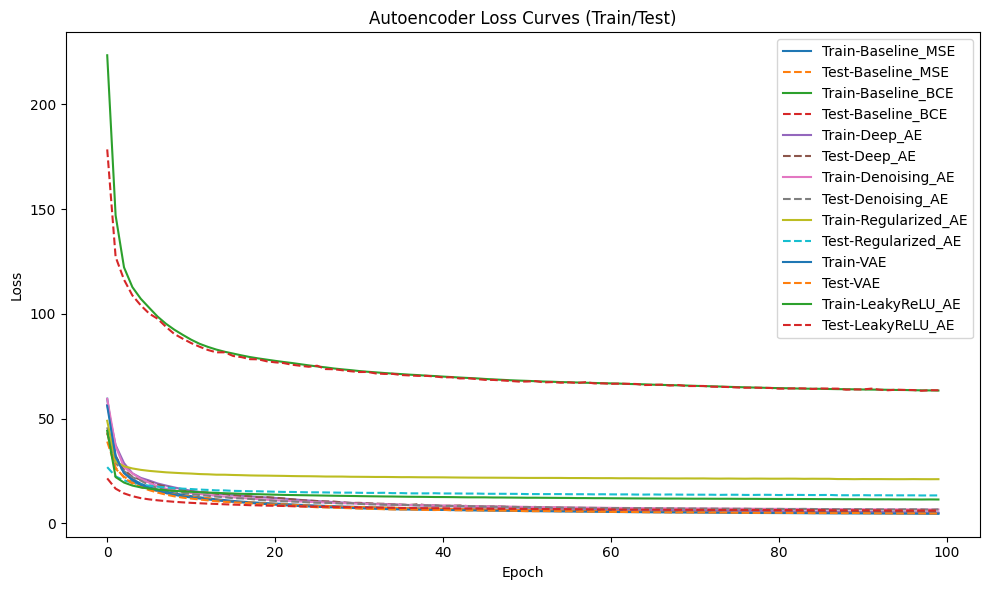

In [102]:
plot_loss_curves(
    history_dict,
    "Autoencoder Loss Curves (Train/Test)",
    save_path="../result/loss_curves_comparison.png"
)

### MSE比较图

MSE comparison chart saved to ../result/mse_comparison.png


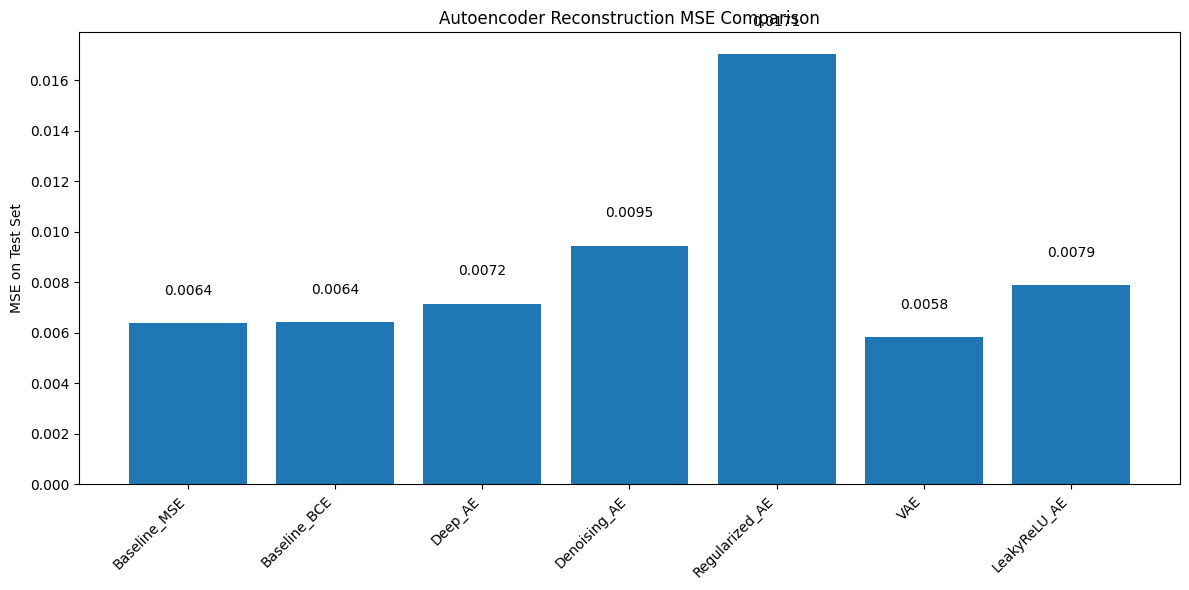


最佳模型是 VAE，MSE: 0.005844
最佳模型已保存到 ../model/best_model.pth


In [103]:
compare_mse(
    recon_mse,
    title="Autoencoder Reconstruction MSE Comparison",
    save_path="../result/mse_comparison.png"
)

print(f"\n最佳模型是 {best_model}，MSE: {best_mse:.6f}")
print(f"最佳模型已保存到 ../model/best_model.pth")